# 환경 통합 작물 질병 진행단계 분류
## EfficientNet B0/B3/B4 + CBAM | D-1 분할 | 그룹×클래스 WeightedSampler

**실험 구성** (모든 실험은 bbox 크롭 전처리 완료 데이터 기준)
- **Exp-1**: B0 — Baseline (BL-1 Feature Extraction vs BL-2 Fine-tuning 포함)
- **Exp-2**: B3 — 핵심 모델
- **Exp-3**: B4 — 선택
- **Exp-4**: B3 + Soft Labeling — 선택

**분석 셀**
- BL-1 vs BL-2 비교 (Exp-1 내)
- 시설/노지 분리 평가 (Exp-2 결과)
- 고추 Cross-Environment 분석 + Grad-CAM
- 개방형 일반화 (held-out 6그룹)


## 0. 환경 설정

In [1]:
!pip install torch torchvision scikit-learn opencv-python-headless matplotlib tqdm -q
!apt-get update -qq
!apt-get install fonts-nanum* -qq

print('설치 완료')

W: https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2404/x86_64/InRelease: Key is stored in legacy trusted.gpg keyring (/etc/apt/trusted.gpg), see the DEPRECATION section in apt-key(8) for details.
설치 완료


In [2]:
import sys, os, json, time
from pathlib import Path
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image as IPImage
from torch.amp import GradScaler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, CosineAnnealingWarmRestarts
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.font_manager as fm
import matplotlib
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_manager = fm.FontProperties(fname=font_path)
fm.fontManager.addfont(font_path)

# 3. 폰트 적용 및 마이너스 기호 깨짐 방지
plt.rc('font', family='NanumGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

WORKSPACE = Path('/workspace')
sys.path.insert(0, str(WORKSPACE))

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = DEVICE.type == 'cuda'
print(f'디바이스: {DEVICE} | AMP: {"ON" if USE_AMP else "OFF"}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

디바이스: cuda | AMP: ON
GPU: NVIDIA RTX PRO 4500 Blackwell


## 1. 공통 설정 (경로 · 하이퍼파라미터)

In [39]:
# ── 경로 ────────────────────────────────────────────
MANIFEST_PATH = '/workspace/data/manifest_all.csv'
DATA_ROOT     = '/workspace/data'          # group_id 폴더가 있는 루트
CKPT_BASE     = '/workspace/checkpoints'
STATS_PATH    = f'{CKPT_BASE}/dataset_stats.json'

# ── 공통 학습 설정 ───────────────────────────────────
NUM_SAMPLES_EP = 60_000   # 에폭당 샘플 수 (WeightedSampler)  [40k→60k]
BATCH_SIZE     = 64
NUM_WORKERS    = 8
EPOCHS         = 35       # [30→50]
PATIENCE       = 7        # [3→7]
FREEZE_EPOCHS  = 3        # [3→5]
LR             = 5e-5     # 1e-4
WEIGHT_DECAY   = 3e-4     # 1e-3
DROPOUT        = 0.3      # 0.6
GAMVAL         = 1.0      # 2.0

# ── 피처 추출 설정 (BL-1용) ─────────────────────────
LIN_EPOCHS  = 50
LIN_BATCH   = 256
LIN_LR      = 1e-3
LIN_DROPOUT = 0.3

from pathlib import Path
Path(CKPT_BASE).mkdir(parents=True, exist_ok=True)
assert Path(MANIFEST_PATH).exists(), f'manifest_all.csv 없음: {MANIFEST_PATH}'
print('설정 완료')
print(f'  manifest: {MANIFEST_PATH}')
print(f'  data_root: {DATA_ROOT}')

설정 완료
  manifest: /workspace/data/manifest_all.csv
  data_root: /workspace/data


## 2. 데이터 로드 (manifest_all.csv 기반)

In [4]:
from dataset import (
    load_all_splits, print_split_summary, print_group_distribution,
    build_dataloaders, compute_dataset_stats,
    RISK_CLASSES, NUM_CLASSES, _MEAN, _STD,
)

# manifest_all.csv 한 번에 로드 → train/val/test/heldout 분리
splits      = load_all_splits(MANIFEST_PATH, DATA_ROOT)
train_s     = splits['train']
val_s       = splits['val']
test_s      = splits['test']
all_heldout = splits['heldout']

print_split_summary(splits)
print_group_distribution(train_s, 'Train 그룹×클래스 분포')

[train] 166,042개 로드  (스킵:0)
  Risk 분포: {'정상': 46925, '초기': 47133, '중기': 44134, '말기': 27850}
[val] 48,595개 로드  (스킵:0)
  Risk 분포: {'정상': 16900, '초기': 12047, '중기': 12719, '말기': 6929}
[test] 48,728개 로드  (스킵:0)
  Risk 분포: {'정상': 16905, '초기': 12165, '중기': 12812, '말기': 6846}
[heldout] 124,934개 로드  (스킵:0)
  Risk 분포: {'정상': 82777, '초기': 15576, '중기': 13905, '말기': 12676}

─────────────────────────────────────────────────────────────────
  데이터셋 요약 (전체 388,299개)
─────────────────────────────────────────────────────────────────
  train   : 166,042개 (42.8%)  {'정상': 46925, '초기': 47133, '중기': 44134, '말기': 27850}
  val     :  48,595개 (12.5%)  {'정상': 16900, '초기': 12047, '중기': 12719, '말기': 6929}
  test    :  48,728개 (12.5%)  {'정상': 16905, '초기': 12165, '중기': 12812, '말기': 6846}
  heldout : 124,934개 (32.2%)  {'정상': 82777, '초기': 15576, '중기': 13905, '말기': 12676}
─────────────────────────────────────────────────────────────────


  [Train 그룹×클래스 분포]
    facility_03_단호박                정상 :  1,925
    facility_03

In [5]:
# 정규화 통계 계산 (저장된 값 있으면 로드)
stats_p = Path(STATS_PATH)
if stats_p.exists():
    stats     = json.load(open(stats_p))
    MEAN, STD = stats['mean'], stats['std']
    print(f'저장된 통계 로드: mean={MEAN}')
else:
    print('통계 계산 중...')
    MEAN, STD = compute_dataset_stats(train_s, model_ver='B0', num_workers=NUM_WORKERS)
    json.dump({'mean': MEAN, 'std': STD}, open(stats_p, 'w'))
    print(f'통계 저장: {stats_p}')

저장된 통계 로드: mean=[0.4441376030445099, 0.49003198742866516, 0.3641504645347595]


## 3. 공통 학습 함수

In [27]:
def train_epoch(model, loader, optimizer, scaler, criterion):
    model.train()
    total_loss, preds_all, lbls_all = 0.0, [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        if USE_AMP:
            with torch.amp.autocast('cuda'):
                logits = model(imgs); loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()
        else:
            logits = model(imgs); loss = criterion(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        total_loss += loss.item()
        preds_all.extend(logits.argmax(1).cpu().tolist())
        lbls_all.extend(labels.cpu().tolist())
    f1 = f1_score(lbls_all, preds_all, average='macro', zero_division=0)
    return {'loss': total_loss / len(loader), 'f1': f1}


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, preds_all, lbls_all = 0.0, [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        if USE_AMP:
            with torch.amp.autocast('cuda'):
                logits = model(imgs); loss = criterion(logits, labels)
        else:
            logits = model(imgs); loss = criterion(logits, labels)
        total_loss += loss.item()
        preds_all.extend(logits.argmax(1).cpu().tolist())
        lbls_all.extend(labels.cpu().tolist())
    f1      = f1_score(lbls_all, preds_all, average='macro', zero_division=0)
    per_cls = f1_score(lbls_all, preds_all, average=None,    zero_division=0)
    return {'loss': total_loss / len(loader), 'f1': f1,
            'per_class_f1': per_cls, 'preds': preds_all, 'labels': lbls_all}


def run_finetune(model, loaders, criterion, save_path,
                 epochs=EPOCHS, freeze_epochs=FREEZE_EPOCHS, patience=PATIENCE):
    """2단계 Fine-tuning 공통 루프. MetricsLogger + plot_all 자동 실행."""
    from plot_results import MetricsLogger, plot_all
    scaler       = GradScaler(enabled=USE_AMP)
    logger       = MetricsLogger()
    best_f1      = patience_cnt = 0
    final_labels = final_preds = None
    opt = sch = None

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        if epoch == 1:
            model.freeze_features()
            opt = AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                        lr=LR * 5, weight_decay=WEIGHT_DECAY)
            sch = CosineAnnealingWarmRestarts(opt, T_0=freeze_epochs, eta_min=1e-5)
            print('▶ Phase 1: features 동결', flush=True)
        elif epoch == freeze_epochs + 1:
            model.unfreeze_features()
            opt = AdamW(model.get_diff_lr_params(LR), weight_decay=WEIGHT_DECAY)
            sch = CosineAnnealingWarmRestarts(opt, T_0=(epochs - freeze_epochs) // 4, T_mult=1, eta_min=1e-6)
            print(f'\n▶ Phase 2: 차등 lr (epoch {epoch})', flush=True)

        phase = 1 if epoch <= freeze_epochs else 2
        tr    = train_epoch(model, loaders['train'], opt, scaler, criterion)
        val   = eval_epoch(model,  loaders['val'],   criterion)
        sch.step()

        lr_now = opt.param_groups[0]['lr']
        gap    = tr['f1'] - val['f1']
        per    = val['per_class_f1']
        logger.update(epoch, tr, val, lr_now, phase)

        print(f'[Ep{epoch:3d}/{epochs} Ph{phase}] '
              f'Tr {tr["loss"]:.4f}/{tr["f1"]:.4f} '
              f'Val {val["loss"]:.4f}/{val["f1"]:.4f} '
              f'Gap={gap:+.3f} [{time.time()-t0:.1f}s]', flush=True)
        print(f'  정상:{per[0]:.3f} 초기:{per[1]:.3f} '
              f'중기:{per[2]:.3f} 말기:{per[3]:.3f}', flush=True)

        if val['f1'] > best_f1:
            best_f1 = val['f1']; patience_cnt = 0
            final_labels = val['labels']; final_preds = val['preds']
            torch.save({'epoch': epoch, 'state_dict': model.state_dict(),
                        'best_f1': best_f1}, save_path)
            print(f'  ✔ Best 저장 ({best_f1:.4f})', flush=True)
        else:
            patience_cnt += 1
        if patience_cnt >= patience:
            print(f'조기 종료 ({patience}에폭)', flush=True); break

    save_dir = str(Path(save_path).parent)
    plot_all(logger, save_dir=save_dir,
             all_labels=final_labels, all_preds=final_preds)
    print(f'\n완료 — Best Val F1: {best_f1:.4f}', flush=True)
    return best_f1, final_labels, final_preds


class FocalLoss(nn.Module):
    """
    Focal Loss — weight=None で使う (WeightedRandomSampler と二重補正防止)
    FL(p) = -(1-p)^gamma * log(p)
    gamma=2.0: 쉬운 샘플(정상) 기여도 억제, 어려운 샘플(말기) 집중
    """
    def __init__(self, gamma: float = 2.0):
        super().__init__()
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # weight=None: WeightedRandomSampler가 이미 불균형 보정
        ce   = F.cross_entropy(logits, targets, reduction='none')
        pt   = torch.exp(-ce)              # 정답 클래스 확률
        loss = (1 - pt) ** self.gamma * ce
        return loss.mean()


def make_criterion():
    """FocalLoss(gamma=2.0, weight=None) 반환.
    WeightedRandomSampler와 동시 사용하므로 클래스 가중치 없음.
    """
    return FocalLoss(gamma=GAMVAL)


def make_test_loader(samples, mean, std, model_ver):
    from dataset import CropDiseaseDataset, get_transforms
    ds = CropDiseaseDataset(samples, get_transforms('val', mean, std, model_ver))
    return torch.utils.data.DataLoader(ds, batch_size=64, shuffle=False)


print('함수 정의 완료')

함수 정의 완료


## 4. Exp-1: B0 Baseline
BL-1 (Feature Extraction) vs BL-2 (Fine-tuning) 비교 포함


In [28]:
EXP1_VER = 'B0'
EXP1_DIR = f'{CKPT_BASE}/exp1_b0'
Path(EXP1_DIR).mkdir(parents=True, exist_ok=True)

from model import EfficientNetCropDisease, SoftLabelLoss

loaders_exp1 = build_dataloaders(
    train_s, val_s, test_s,
    batch_size  = BATCH_SIZE,
    num_workers = NUM_WORKERS,
    num_samples = NUM_SAMPLES_EP,
    mean        = MEAN, std = STD,
    model_ver   = EXP1_VER,
)
crit_exp1 = make_criterion()
print('Exp-1 DataLoader 구성 완료')


  [WeightedRandomSampler] 그룹×클래스 역빈도
    facility_03_단호박                정상 :  1,925개  w=5.19e-04
    facility_03_단호박                초기 :  4,455개  w=2.24e-04
    facility_03_단호박                중기 :  4,169개  w=2.40e-04
    facility_03_단호박                말기 :  2,057개  w=4.86e-04
    facility_04_딸기                 정상 :  5,000개  w=2.00e-04
    facility_04_딸기                 초기 :  5,000개  w=2.00e-04
    facility_04_딸기                 중기 :  3,806개  w=2.63e-04
    facility_04_딸기                 말기 :  2,662개  w=3.76e-04
    facility_05_상추                 정상 :  5,000개  w=2.00e-04
    facility_05_상추                 초기 :  5,000개  w=2.00e-04
    facility_05_상추                 중기 :  5,000개  w=2.00e-04
    facility_05_상추                 말기 :  5,000개  w=2.00e-04
    facility_09_쥬키니호박              정상 :  5,000개  w=2.00e-04
    facility_09_쥬키니호박              초기 :  4,281개  w=2.34e-04
    facility_09_쥬키니호박              중기 :  4,479개  w=2.23e-04
    facility_09_쥬키니호박              말기 :  3,748개  w=2.67e-04
  

In [29]:
# ── BL-1: Feature Extraction ──────────────────────────
from plot_linear import LinearMetricsLogger, plot_linear_results
from dataset import CropDiseaseDataset, get_transforms
from torch.utils.data import DataLoader as DL, TensorDataset

BL1_FEAT_TRAIN = f'{CKPT_BASE}/feat_b0/train'
BL1_FEAT_VAL   = f'{CKPT_BASE}/feat_b0/val'

def extract_features(samples, save_dir, mean, std, model_ver, desc='추출'):
    feat_p = Path(save_dir) / 'features.npy'
    lbl_p  = Path(save_dir) / 'labels.npy'
    if feat_p.exists() and lbl_p.exists():
        print(f'{desc}: 이미 존재 → 건너뜀'); return
    extractor = EfficientNetCropDisease(model_ver=model_ver).to(DEVICE).eval()
    for p in extractor.parameters(): p.requires_grad = False
    ds     = CropDiseaseDataset(samples, get_transforms('val', mean, std, model_ver))
    loader = DL(ds, batch_size=64, shuffle=False, num_workers=NUM_WORKERS)
    vecs, lbls = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE, non_blocking=True)
            x    = extractor.features(imgs)
            x    = extractor.cbam(x)
            vecs.append(extractor.pool(x).flatten(1).cpu().numpy())
            lbls.append(labels.numpy())
    Path(save_dir).mkdir(parents=True, exist_ok=True)
    np.save(feat_p, np.vstack(vecs))
    np.save(lbl_p,  np.concatenate(lbls))
    print(f'{desc} 완료: {np.vstack(vecs).shape}', flush=True)

extract_features(train_s, BL1_FEAT_TRAIN, MEAN, STD, 'B0', 'Train 피처 추출')
extract_features(val_s,   BL1_FEAT_VAL,   MEAN, STD, 'B0', 'Val 피처 추출')
print('피처 추출 완료')

Train 피처 추출: 이미 존재 → 건너뜀
Val 피처 추출: 이미 존재 → 건너뜀
피처 추출 완료


BL-1 [  1/50] Tr=0.6154 Val=1.1354 F1=0.6193 | 정상:0.920 초기:0.570 중기:0.482 말기:0.506
  ✔ BL-1 Best (0.6193)
BL-1 [  2/50] Tr=0.5282 Val=1.2706 F1=0.6207 | 정상:0.937 초기:0.598 중기:0.385 말기:0.562
  ✔ BL-1 Best (0.6207)
BL-1 [  3/50] Tr=0.4966 Val=1.2183 F1=0.6406 | 정상:0.948 초기:0.603 중기:0.460 말기:0.552
  ✔ BL-1 Best (0.6406)
BL-1 [  4/50] Tr=0.4741 Val=1.3161 F1=0.6240 | 정상:0.955 초기:0.603 중기:0.376 말기:0.562
BL-1 [  5/50] Tr=0.4575 Val=1.3860 F1=0.6341 | 정상:0.954 초기:0.588 중기:0.481 말기:0.514
BL-1 [  6/50] Tr=0.4425 Val=1.2869 F1=0.6555 | 정상:0.960 초기:0.601 중기:0.513 말기:0.548
  ✔ BL-1 Best (0.6555)
BL-1 [  7/50] Tr=0.4325 Val=1.3604 F1=0.6518 | 정상:0.958 초기:0.585 중기:0.522 말기:0.543
BL-1 [  8/50] Tr=0.4221 Val=1.4878 F1=0.6453 | 정상:0.956 초기:0.590 중기:0.473 말기:0.562
BL-1 [  9/50] Tr=0.4115 Val=1.5024 F1=0.6495 | 정상:0.961 초기:0.596 중기:0.498 말기:0.543
BL-1 [ 10/50] Tr=0.4054 Val=1.5372 F1=0.6505 | 정상:0.960 초기:0.585 중기:0.494 말기:0.564
BL-1 [ 11/50] Tr=0.3974 Val=1.5208 F1=0.6604 | 정상:0.962 초기:0.607 중기:0.503 말기:0

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

학습 곡선 저장: /workspace/checkpoints/exp1_b0/bl1_curves.png

BL-1 완료 — Best Val F1: 0.6604


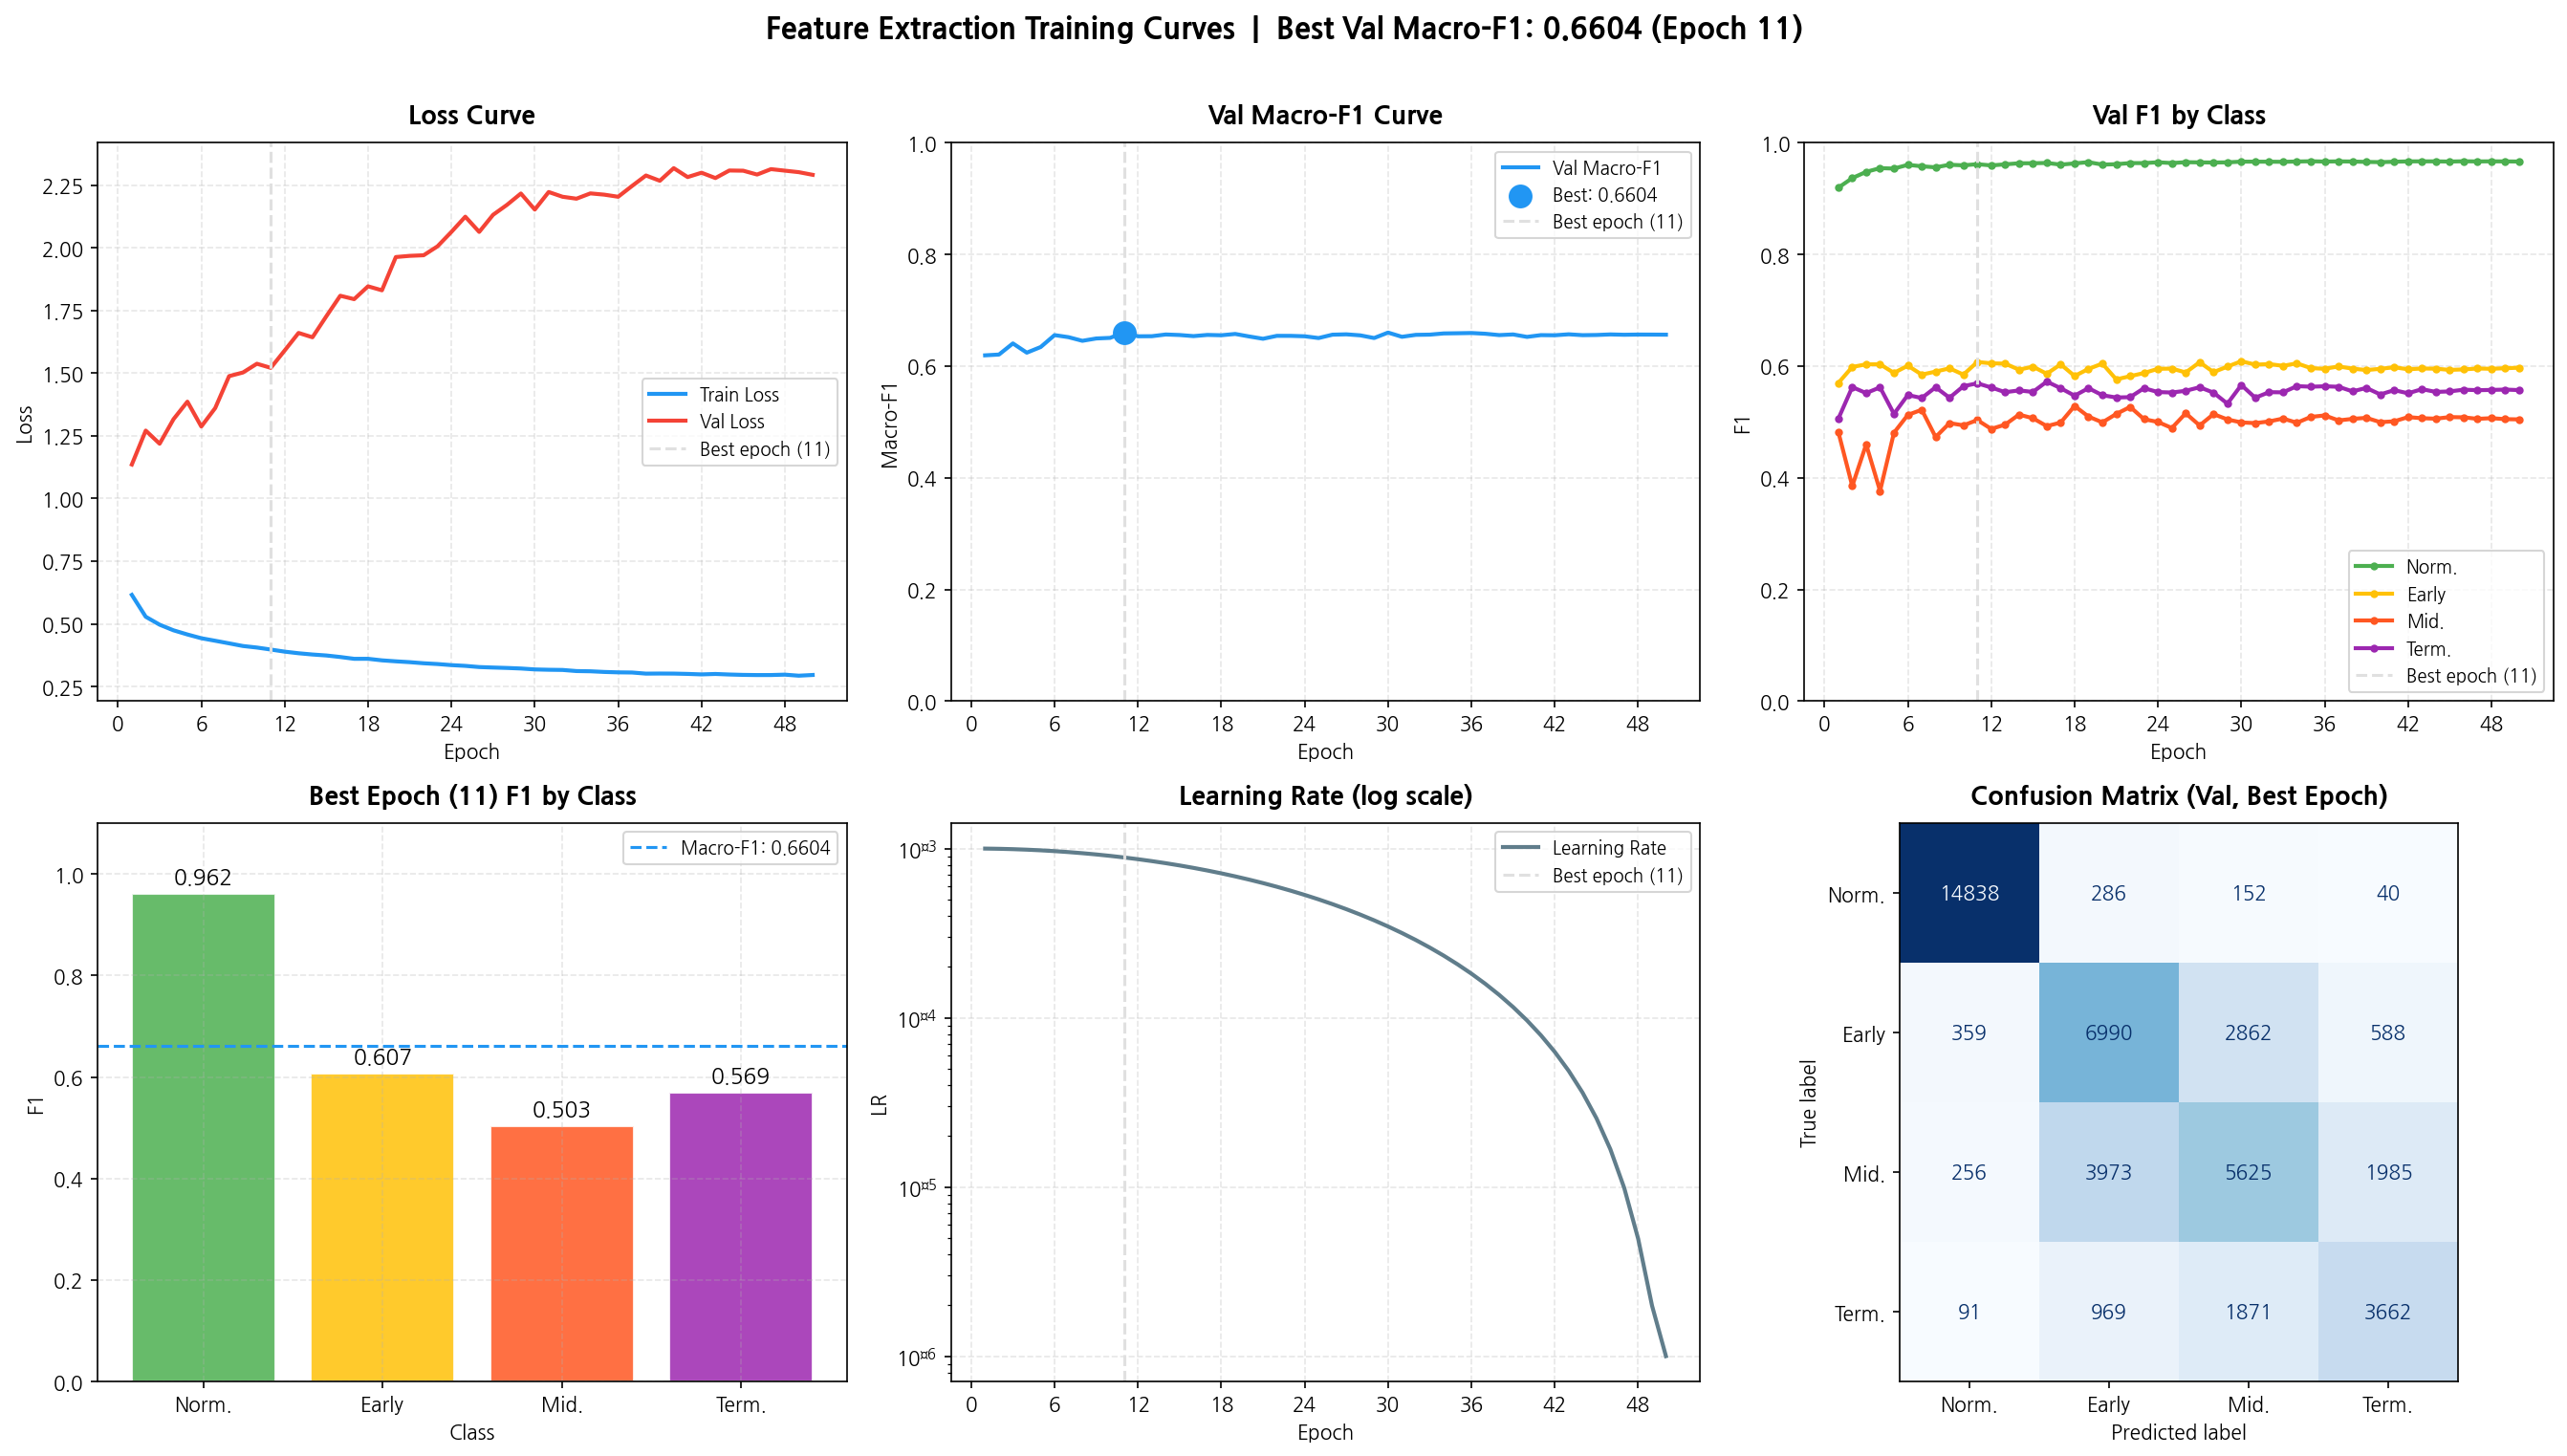

In [30]:
# BL-1 MLP 학습
X_tr  = torch.tensor(np.load(f'{BL1_FEAT_TRAIN}/features.npy'), dtype=torch.float32)
y_tr  = torch.tensor(np.load(f'{BL1_FEAT_TRAIN}/labels.npy'),   dtype=torch.long)
X_val = torch.tensor(np.load(f'{BL1_FEAT_VAL}/features.npy'),   dtype=torch.float32)
y_val = torch.tensor(np.load(f'{BL1_FEAT_VAL}/labels.npy'),     dtype=torch.long)

out_ch = EfficientNetCropDisease(model_ver='B0').out_ch
bl1_cls = nn.Sequential(
    nn.Dropout(0.5), nn.Linear(out_ch, 512), nn.BatchNorm1d(512),
    nn.ReLU(inplace=True), nn.Dropout(LIN_DROPOUT), nn.Linear(512, NUM_CLASSES),
).to(DEVICE)

# BL-1 MLP도 FocalLoss 사용 (피처 추출 단계도 일관성 유지)
crit_lin = make_criterion()
tr_ldr   = DL(TensorDataset(X_tr, y_tr),   batch_size=LIN_BATCH, shuffle=True)
val_ldr  = DL(TensorDataset(X_val, y_val), batch_size=LIN_BATCH, shuffle=False)
opt_lin  = AdamW(bl1_cls.parameters(), lr=LIN_LR, weight_decay=1e-4)
sch_lin  = CosineAnnealingLR(opt_lin, T_max=LIN_EPOCHS, eta_min=1e-6)

logger_bl1  = LinearMetricsLogger()
best_bl1_f1 = 0.0; bl1_lbl = bl1_pred = []

for epoch in range(1, LIN_EPOCHS + 1):
    bl1_cls.train()
    tl = 0.0
    for X_b, y_b in tr_ldr:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        opt_lin.zero_grad()
        loss = crit_lin(bl1_cls(X_b), y_b)
        loss.backward(); opt_lin.step()
        tl += loss.item()
    tl /= len(tr_ldr)
    bl1_cls.eval()
    ep, lp, vl = [], [], 0.0
    with torch.no_grad():
        for X_b, y_b in val_ldr:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            out = bl1_cls(X_b)
            vl += crit_lin(out, y_b).item()
            ep.extend(out.argmax(1).cpu().tolist())
            lp.extend(y_b.cpu().tolist())
    vl /= len(val_ldr)
    vf1 = f1_score(lp, ep, average='macro', zero_division=0)
    pcf = f1_score(lp, ep, average=None,    zero_division=0)
    sch_lin.step()
    logger_bl1.update(epoch, vf1, pcf, opt_lin.param_groups[0]['lr'],
                      train_loss=tl, val_loss=vl)
    print(f'BL-1 [{epoch:3d}/{LIN_EPOCHS}] Tr={tl:.4f} Val={vl:.4f} F1={vf1:.4f} | '
          f'정상:{pcf[0]:.3f} 초기:{pcf[1]:.3f} 중기:{pcf[2]:.3f} 말기:{pcf[3]:.3f}',
          flush=True)
    if vf1 > best_bl1_f1:
        best_bl1_f1 = vf1; bl1_lbl = lp.copy(); bl1_pred = ep.copy()
        torch.save(bl1_cls.state_dict(), f'{EXP1_DIR}/bl1_best.pth')
        print(f'  ✔ BL-1 Best ({best_bl1_f1:.4f})', flush=True)

plot_linear_results(logger_bl1, save_dir=EXP1_DIR,
                    all_labels=bl1_lbl, all_preds=bl1_pred, filename='bl1_curves.png')
print(f'\nBL-1 완료 — Best Val F1: {best_bl1_f1:.4f}')
IPImage(f'{EXP1_DIR}/bl1_curves.png')

### 공통 함수 — 피처 추출 + MLP 학습 + fc 이식

In [31]:
def run_feature_extraction(ver, feat_dir_train, feat_dir_val,
                            samples_train, samples_val,
                            mean, std, save_path):
    """
    1. 피처 추출 (features + CBAM + pool → 1280/1536/1792-d 벡터)
    2. MLP 학습 (BL-1과 동일 구조)
    3. 학습된 fc 가중치 반환
    """
    # 피처 추출
    extract_features(samples_train, feat_dir_train, mean, std, ver, f'{ver} Train 피처')
    extract_features(samples_val,   feat_dir_val,   mean, std, ver, f'{ver} Val 피처')

    # 피처 로드
    X_tr  = torch.tensor(np.load(f'{feat_dir_train}/features.npy'), dtype=torch.float32)
    y_tr  = torch.tensor(np.load(f'{feat_dir_train}/labels.npy'),   dtype=torch.long)
    X_val = torch.tensor(np.load(f'{feat_dir_val}/features.npy'),   dtype=torch.float32)
    y_val = torch.tensor(np.load(f'{feat_dir_val}/labels.npy'),     dtype=torch.long)

    out_ch = EfficientNetCropDisease(model_ver=ver).out_ch
    print(f'{ver} out_ch: {out_ch}')

    # MLP 구성
    clf = nn.Sequential(
        nn.Dropout(0.5), nn.Linear(out_ch, 512), nn.BatchNorm1d(512),
        nn.ReLU(inplace=True), nn.Dropout(LIN_DROPOUT), nn.Linear(512, NUM_CLASSES),
    ).to(DEVICE)

    # FocalLoss: WeightedRandomSampler와 이중 보정 방지
    crit = make_criterion()
    tr_ldr  = torch.utils.data.DataLoader(
        TensorDataset(X_tr, y_tr),   batch_size=LIN_BATCH, shuffle=True)
    val_ldr = torch.utils.data.DataLoader(
        TensorDataset(X_val, y_val), batch_size=LIN_BATCH, shuffle=False)
    opt = AdamW(clf.parameters(), lr=LIN_LR, weight_decay=1e-4)
    sch = CosineAnnealingLR(opt, T_max=LIN_EPOCHS, eta_min=1e-6)

    logger = LinearMetricsLogger()
    best_f1 = 0.0
    best_lbl = best_pred = []

    for epoch in range(1, LIN_EPOCHS + 1):
        clf.train()
        tl = 0.0
        for X_b, y_b in tr_ldr:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            opt.zero_grad()
            loss = crit(clf(X_b), y_b)
            loss.backward(); opt.step()
            tl += loss.item()
        tl /= len(tr_ldr)
        clf.eval()
        ep, lp, vl = [], [], 0.0
        with torch.no_grad():
            for X_b, y_b in val_ldr:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                out = clf(X_b)
                vl += crit(out, y_b).item()
                ep.extend(out.argmax(1).cpu().tolist())
                lp.extend(y_b.cpu().tolist())
        vl /= len(val_ldr)
        vf1 = f1_score(lp, ep, average='macro', zero_division=0)
        pcf = f1_score(lp, ep, average=None,    zero_division=0)
        sch.step()
        logger.update(epoch, vf1, pcf, opt.param_groups[0]['lr'],
                      train_loss=tl, val_loss=vl)
        print(f'[{ver} BL-1 {epoch:3d}/{LIN_EPOCHS}] '
              f'Tr={tl:.4f} Val={vl:.4f} F1={vf1:.4f} | '
              f'정상:{pcf[0]:.3f} 초기:{pcf[1]:.3f} 중기:{pcf[2]:.3f} 말기:{pcf[3]:.3f}',
              flush=True)
        if vf1 > best_f1:
            best_f1 = vf1; best_lbl = lp.copy(); best_pred = ep.copy()
            torch.save(clf.state_dict(), save_path)
            print(f'  ✔ Best ({best_f1:.4f})', flush=True)

    plot_linear_results(logger, save_dir=str(Path(save_path).parent),
                        all_labels=best_lbl, all_preds=best_pred,
                        filename=f'bl1_curves_{ver}.png')
    print(f'{ver} BL-1 완료 — Best Val F1: {best_f1:.4f}')
    return clf.state_dict(), best_f1


def transplant_fc(model, state_dict):
    """BL-1 학습된 fc 가중치를 Fine-tuning 모델에 이식."""
    model.fc[1].weight.data.copy_(state_dict['1.weight'])
    model.fc[1].bias.data.copy_(state_dict['1.bias'])
    model.fc[2].weight.data.copy_(state_dict['2.weight'])
    model.fc[2].bias.data.copy_(state_dict['2.bias'])
    model.fc[2].running_mean.copy_(state_dict['2.running_mean'])
    model.fc[2].running_var.copy_(state_dict['2.running_var'])
    model.fc[2].num_batches_tracked.copy_(state_dict['2.num_batches_tracked'])
    model.fc[5].weight.data.copy_(state_dict['5.weight'])
    model.fc[5].bias.data.copy_(state_dict['5.bias'])
    print('fc 가중치 이식 완료', flush=True)


fc 가중치 이식 완료 (BL-1 → BL-2)
▶ Phase 1: features 동결
[Ep  1/35 Ph1] Tr 0.8555/0.4975 Val 0.6875/0.4382 Gap=+0.059 [49.1s]
  정상:0.667 초기:0.393 중기:0.306 말기:0.387
  ✔ Best 저장 (0.4382)
[Ep  2/35 Ph1] Tr 0.6837/0.5551 Val 0.6741/0.4488 Gap=+0.106 [47.5s]
  정상:0.675 초기:0.419 중기:0.292 말기:0.410
  ✔ Best 저장 (0.4488)
[Ep  3/35 Ph1] Tr 0.6396/0.5753 Val 0.6643/0.4600 Gap=+0.115 [47.4s]
  정상:0.678 초기:0.413 중기:0.331 말기:0.418
  ✔ Best 저장 (0.4600)

▶ Phase 2: 차등 lr (epoch 4)
[Ep  4/35 Ph2] Tr 0.5809/0.6083 Val 0.6351/0.4787 Gap=+0.130 [57.7s]
  정상:0.688 초기:0.441 중기:0.348 말기:0.438
  ✔ Best 저장 (0.4787)
[Ep  5/35 Ph2] Tr 0.5202/0.6435 Val 0.6178/0.4876 Gap=+0.156 [57.4s]
  정상:0.695 초기:0.449 중기:0.347 말기:0.459
  ✔ Best 저장 (0.4876)
[Ep  6/35 Ph2] Tr 0.4811/0.6664 Val 0.5991/0.5623 Gap=+0.104 [57.7s]
  정상:0.844 초기:0.458 중기:0.485 말기:0.462
  ✔ Best 저장 (0.5623)
[Ep  7/35 Ph2] Tr 0.4586/0.6803 Val 0.5894/0.5707 Gap=+0.110 [59.6s]
  정상:0.844 초기:0.480 중기:0.482 말기:0.478
  ✔ Best 저장 (0.5707)
[Ep  8/35 Ph2] Tr 0.4426/0

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

학습 곡선 저장: /workspace/checkpoints/exp1_b0/training_curves.png

완료 — Best Val F1: 0.5867


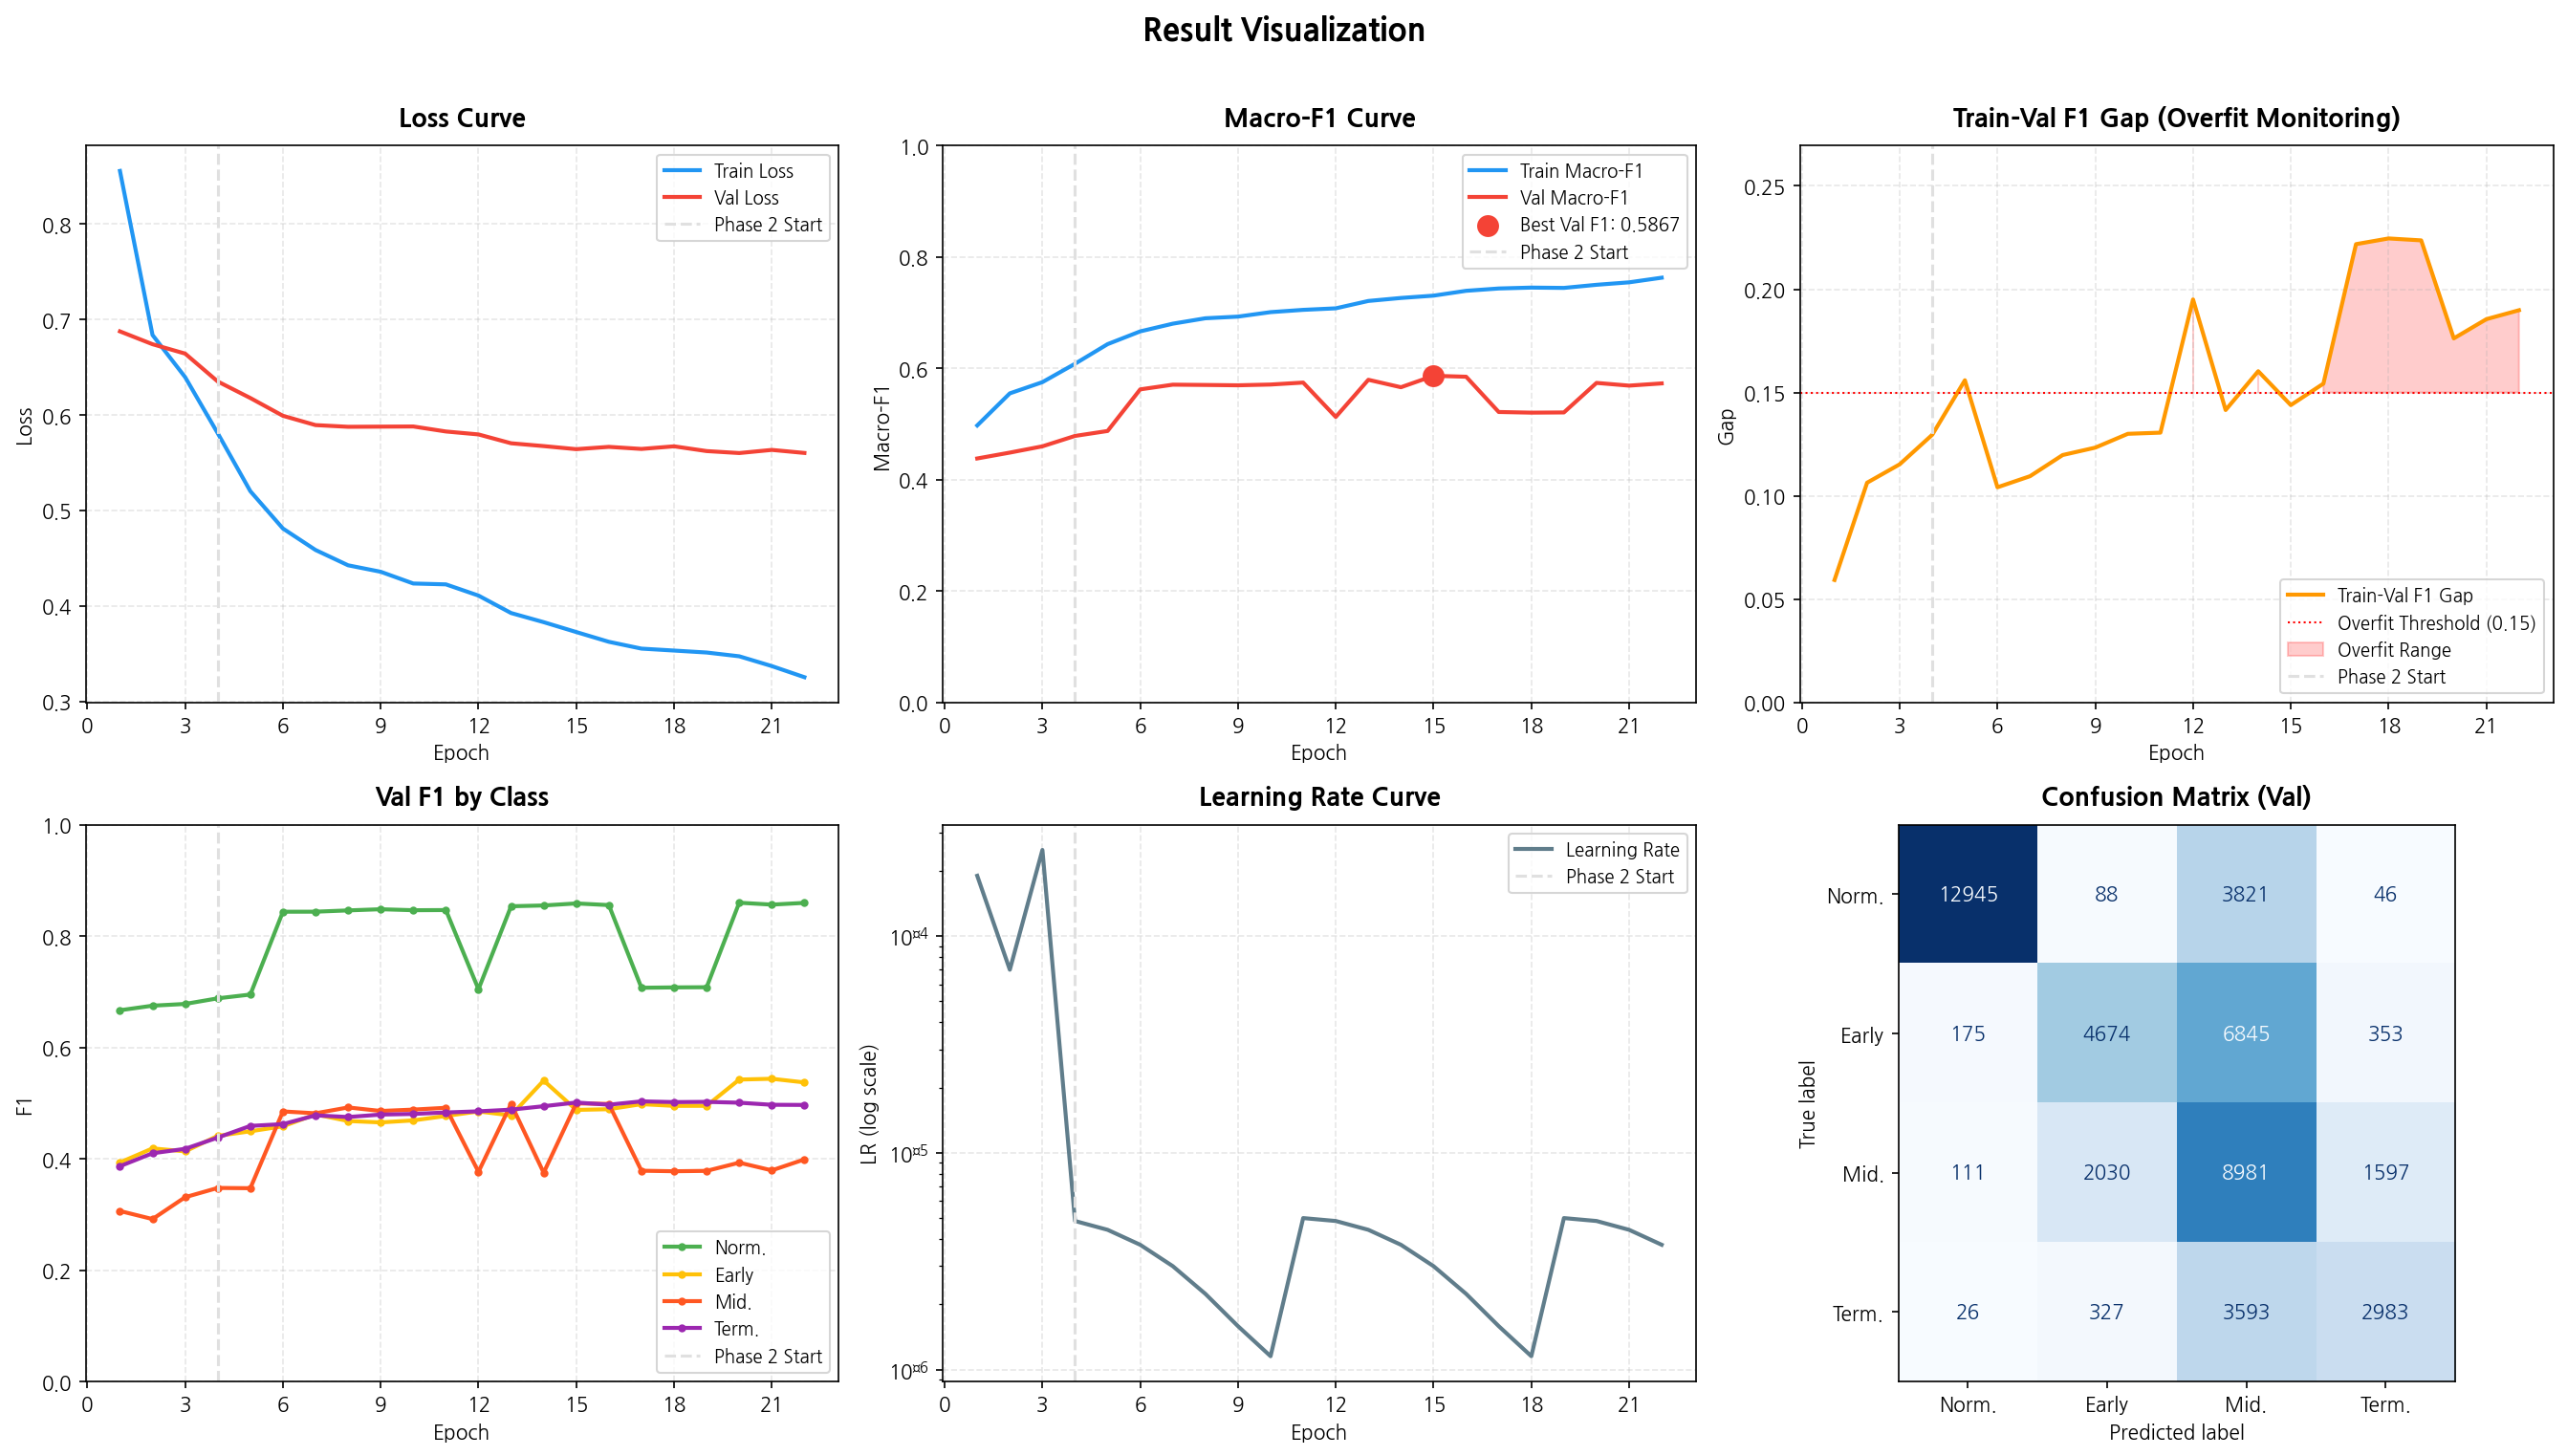

In [32]:
# ── BL-2: Fine-tuning ─────────────────────────────────
model_exp1 = EfficientNetCropDisease(NUM_CLASSES, DROPOUT, EXP1_VER).to(DEVICE)

# fc 가중치 이식 (BL-1 학습 결과 → BL-2 초기값)
bl1_state = torch.load(f'{EXP1_DIR}/bl1_best.pth', map_location=DEVICE)
model_exp1.fc[1].weight.data.copy_(bl1_state['1.weight'])
model_exp1.fc[1].bias.data.copy_(bl1_state['1.bias'])
model_exp1.fc[2].weight.data.copy_(bl1_state['2.weight'])
model_exp1.fc[2].bias.data.copy_(bl1_state['2.bias'])
model_exp1.fc[2].running_mean.copy_(bl1_state['2.running_mean'])
model_exp1.fc[2].running_var.copy_(bl1_state['2.running_var'])
model_exp1.fc[2].num_batches_tracked.copy_(bl1_state['2.num_batches_tracked'])
model_exp1.fc[5].weight.data.copy_(bl1_state['5.weight'])
model_exp1.fc[5].bias.data.copy_(bl1_state['5.bias'])
print('fc 가중치 이식 완료 (BL-1 → BL-2)', flush=True)

best_exp1_f1, exp1_lbl, exp1_pred = run_finetune(
    model_exp1, loaders_exp1, crit_exp1, f'{EXP1_DIR}/bl2_best.pth')
IPImage(f'{EXP1_DIR}/training_curves.png')

In [33]:
# BL-1 vs BL-2 비교
print('\n' + '='*50)
print('BL-1 vs BL-2 비교 (Exp-1, B0)')
print('='*50)
print(f'  BL-1 Feature Extraction: Val F1 = {best_bl1_f1:.4f}')
print(f'  BL-2 Fine-tuning:        Val F1 = {best_exp1_f1:.4f}')
diff = best_exp1_f1 - best_bl1_f1
print(f'  Fine-tuning 향상폭:      {diff:+.4f} ({diff/best_bl1_f1*100:+.1f}%)')
print('='*50)


BL-1 vs BL-2 비교 (Exp-1, B0)
  BL-1 Feature Extraction: Val F1 = 0.6604
  BL-2 Fine-tuning:        Val F1 = 0.5867
  Fine-tuning 향상폭:      -0.0737 (-11.2%)


## 5. Exp-2: B3 (핵심 모델)

In [34]:
EXP2_VER = 'B3'
EXP2_DIR = f'{CKPT_BASE}/exp2_b3'
Path(EXP2_DIR).mkdir(parents=True, exist_ok=True)

# B3용 정규화 통계
stats2_p = Path(f'{CKPT_BASE}/dataset_stats_b3.json')
if stats2_p.exists():
    s2 = json.load(open(stats2_p))
    MEAN2, STD2 = s2['mean'], s2['std']
    print(f'B3 통계 로드: {MEAN2}')
else:
    print('B3 통계 계산 중...')
    MEAN2, STD2 = compute_dataset_stats(train_s, model_ver='B3', num_workers=NUM_WORKERS)
    json.dump({'mean': MEAN2, 'std': STD2}, open(stats2_p, 'w'))

loaders_exp2 = build_dataloaders(
    train_s, val_s, test_s,
    batch_size  = BATCH_SIZE,
    num_workers = NUM_WORKERS,
    num_samples = NUM_SAMPLES_EP,
    mean        = MEAN2, std = STD2,
    model_ver   = EXP2_VER,
)
crit_exp2  = make_criterion()



B3 통계 로드: [0.4441218674182892, 0.4900154769420624, 0.36413559317588806]

  [WeightedRandomSampler] 그룹×클래스 역빈도
    facility_03_단호박                정상 :  1,925개  w=5.19e-04
    facility_03_단호박                초기 :  4,455개  w=2.24e-04
    facility_03_단호박                중기 :  4,169개  w=2.40e-04
    facility_03_단호박                말기 :  2,057개  w=4.86e-04
    facility_04_딸기                 정상 :  5,000개  w=2.00e-04
    facility_04_딸기                 초기 :  5,000개  w=2.00e-04
    facility_04_딸기                 중기 :  3,806개  w=2.63e-04
    facility_04_딸기                 말기 :  2,662개  w=3.76e-04
    facility_05_상추                 정상 :  5,000개  w=2.00e-04
    facility_05_상추                 초기 :  5,000개  w=2.00e-04
    facility_05_상추                 중기 :  5,000개  w=2.00e-04
    facility_05_상추                 말기 :  5,000개  w=2.00e-04
    facility_09_쥬키니호박              정상 :  5,000개  w=2.00e-04
    facility_09_쥬키니호박              초기 :  4,281개  w=2.34e-04
    facility_09_쥬키니호박              중기 :  4,479개  w

#### Exp-2 B3: BL-1 피처 추출 + MLP 학습 + fc 이식

B3 Train 피처: 이미 존재 → 건너뜀
B3 Val 피처: 이미 존재 → 건너뜀
B3 out_ch: 1536
[B3 BL-1   1/50] Tr=0.5863 Val=0.7182 F1=0.6108 | 정상:0.886 초기:0.524 중기:0.490 말기:0.543
  ✔ Best (0.6108)
[B3 BL-1   2/50] Tr=0.5048 Val=0.7353 F1=0.6069 | 정상:0.899 초기:0.482 중기:0.500 말기:0.546
[B3 BL-1   3/50] Tr=0.4732 Val=0.7663 F1=0.6206 | 정상:0.906 초기:0.537 중기:0.490 말기:0.549
  ✔ Best (0.6206)
[B3 BL-1   4/50] Tr=0.4539 Val=0.7813 F1=0.6223 | 정상:0.911 초기:0.570 중기:0.456 말기:0.553
  ✔ Best (0.6223)
[B3 BL-1   5/50] Tr=0.4368 Val=0.8544 F1=0.6164 | 정상:0.911 초기:0.568 중기:0.430 말기:0.557
[B3 BL-1   6/50] Tr=0.4233 Val=0.9296 F1=0.6148 | 정상:0.906 초기:0.544 중기:0.456 말기:0.553
[B3 BL-1   7/50] Tr=0.4117 Val=0.9479 F1=0.6208 | 정상:0.907 초기:0.523 중기:0.497 말기:0.556
[B3 BL-1   8/50] Tr=0.4016 Val=1.0462 F1=0.6201 | 정상:0.911 초기:0.544 중기:0.471 말기:0.553
[B3 BL-1   9/50] Tr=0.3926 Val=1.0491 F1=0.6202 | 정상:0.919 초기:0.551 중기:0.456 말기:0.556
[B3 BL-1  10/50] Tr=0.3855 Val=1.1342 F1=0.6124 | 정상:0.914 초기:0.531 중기:0.452 말기:0.554
[B3 BL-1  11/50] Tr=0.

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

학습 곡선 저장: /workspace/checkpoints/exp2_b3/bl1_curves_B3.png
B3 BL-1 완료 — Best Val F1: 0.6263


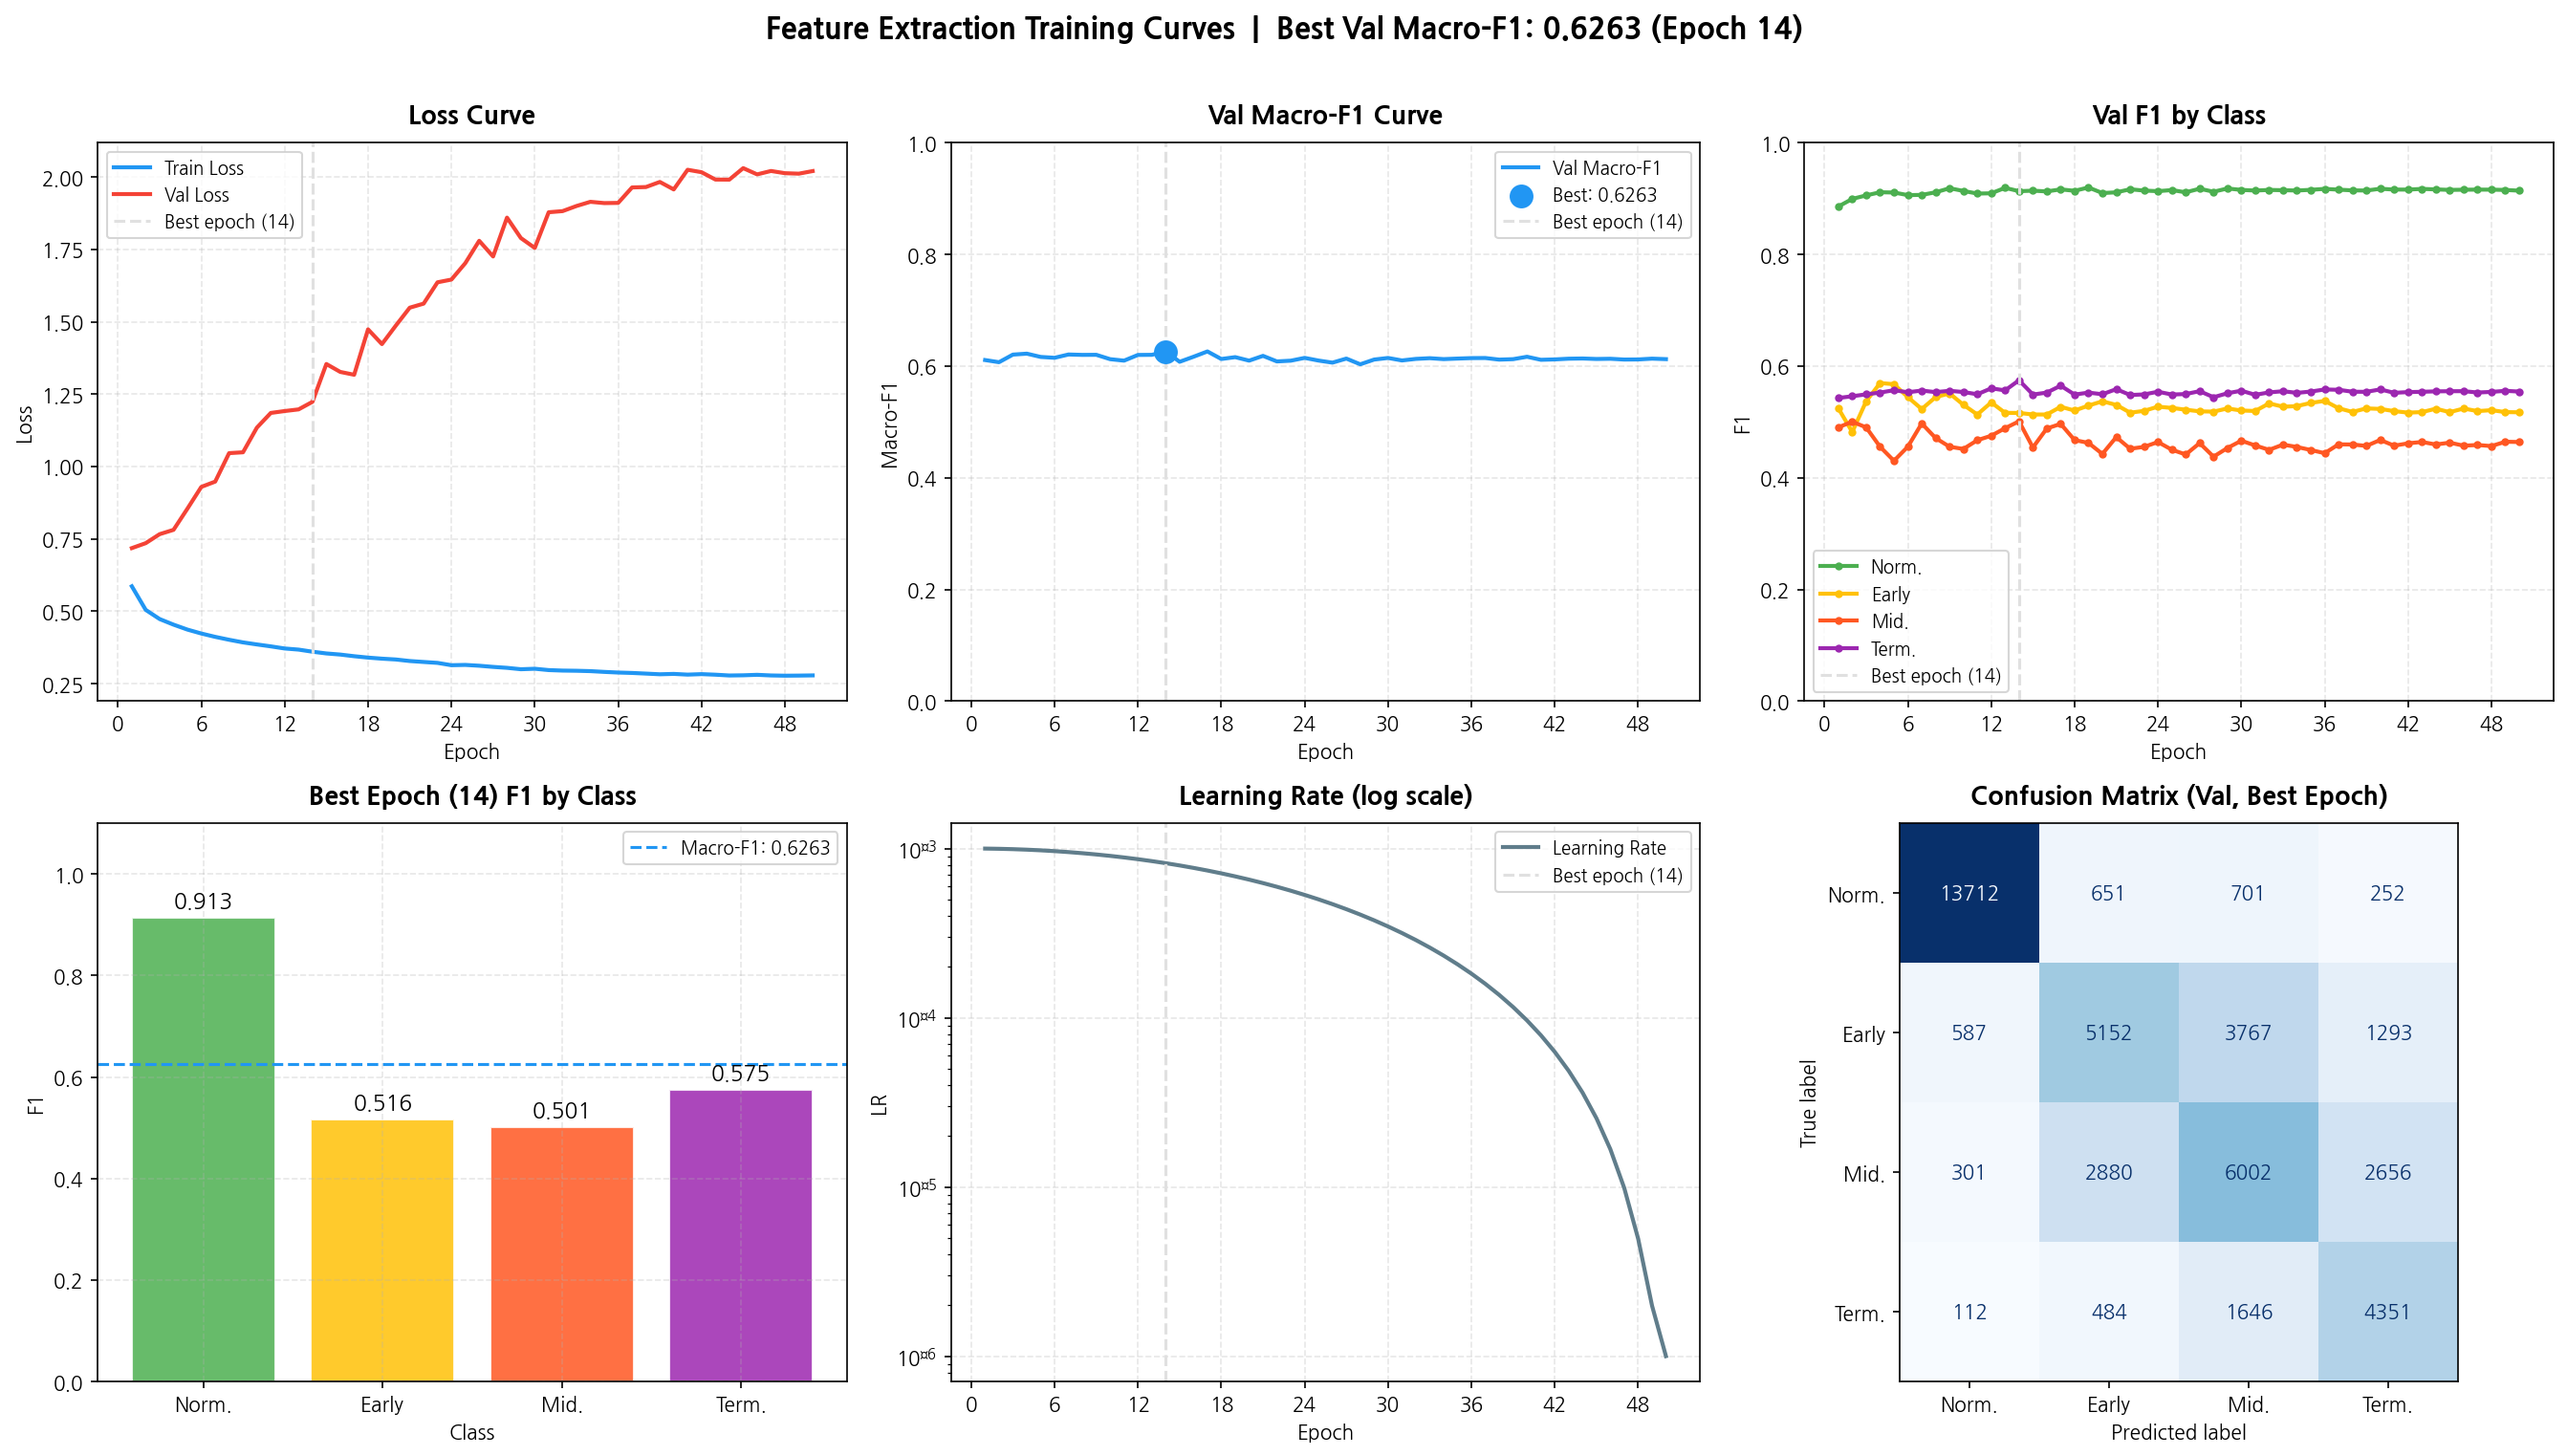

In [35]:
# ── Exp-2 B3: BL-1 피처 추출 + MLP 학습 + fc 이식 ──────
BL1_FEAT_TRAIN_B3 = f'{CKPT_BASE}/feat_b3/train'
BL1_FEAT_VAL_B3   = f'{CKPT_BASE}/feat_b3/val'

bl1_state_b3, best_bl1_b3 = run_feature_extraction(
    ver          = EXP2_VER,
    feat_dir_train = BL1_FEAT_TRAIN_B3,
    feat_dir_val   = BL1_FEAT_VAL_B3,
    samples_train  = train_s,
    samples_val    = val_s,
    mean           = MEAN2,
    std            = STD2,
    save_path      = f'{EXP2_DIR}/bl1_best_b3.pth',
)
IPImage(f'{EXP2_DIR}/bl1_curves_B3.png')

fc 가중치 이식 완료
▶ Phase 1: features 동결
[Ep  1/35 Ph1] Tr 1.1494/0.4356 Val 0.7380/0.4479 Gap=-0.012 [71.3s]
  정상:0.790 초기:0.343 중기:0.311 말기:0.348
  ✔ Best 저장 (0.4479)
[Ep  2/35 Ph1] Tr 0.8217/0.4984 Val 0.6979/0.4936 Gap=+0.005 [69.4s]
  정상:0.811 초기:0.478 중기:0.299 말기:0.386
  ✔ Best 저장 (0.4936)
[Ep  3/35 Ph1] Tr 0.7424/0.5271 Val 0.7043/0.4413 Gap=+0.086 [69.5s]
  정상:0.676 초기:0.400 중기:0.289 말기:0.400

▶ Phase 2: 차등 lr (epoch 4)
[Ep  4/35 Ph2] Tr 0.6556/0.5645 Val 0.6390/0.5296 Gap=+0.035 [154.8s]
  정상:0.842 초기:0.516 중기:0.322 말기:0.439
  ✔ Best 저장 (0.5296)
[Ep  5/35 Ph2] Tr 0.5662/0.6146 Val 0.6102/0.5632 Gap=+0.051 [153.6s]
  정상:0.855 초기:0.465 중기:0.478 말기:0.455
  ✔ Best 저장 (0.5632)
[Ep  6/35 Ph2] Tr 0.5157/0.6445 Val 0.5926/0.5723 Gap=+0.072 [154.0s]
  정상:0.860 초기:0.470 중기:0.492 말기:0.467
  ✔ Best 저장 (0.5723)
[Ep  7/35 Ph2] Tr 0.4820/0.6625 Val 0.5841/0.5780 Gap=+0.085 [154.6s]
  정상:0.858 초기:0.486 중기:0.485 말기:0.483
  ✔ Best 저장 (0.5780)
[Ep  8/35 Ph2] Tr 0.4552/0.6757 Val 0.5796/0.5817 Gap=+0.

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

학습 곡선 저장: /workspace/checkpoints/exp2_b3/training_curves.png

완료 — Best Val F1: 0.5999
Exp-2 완료 — Best Val F1: 0.5999


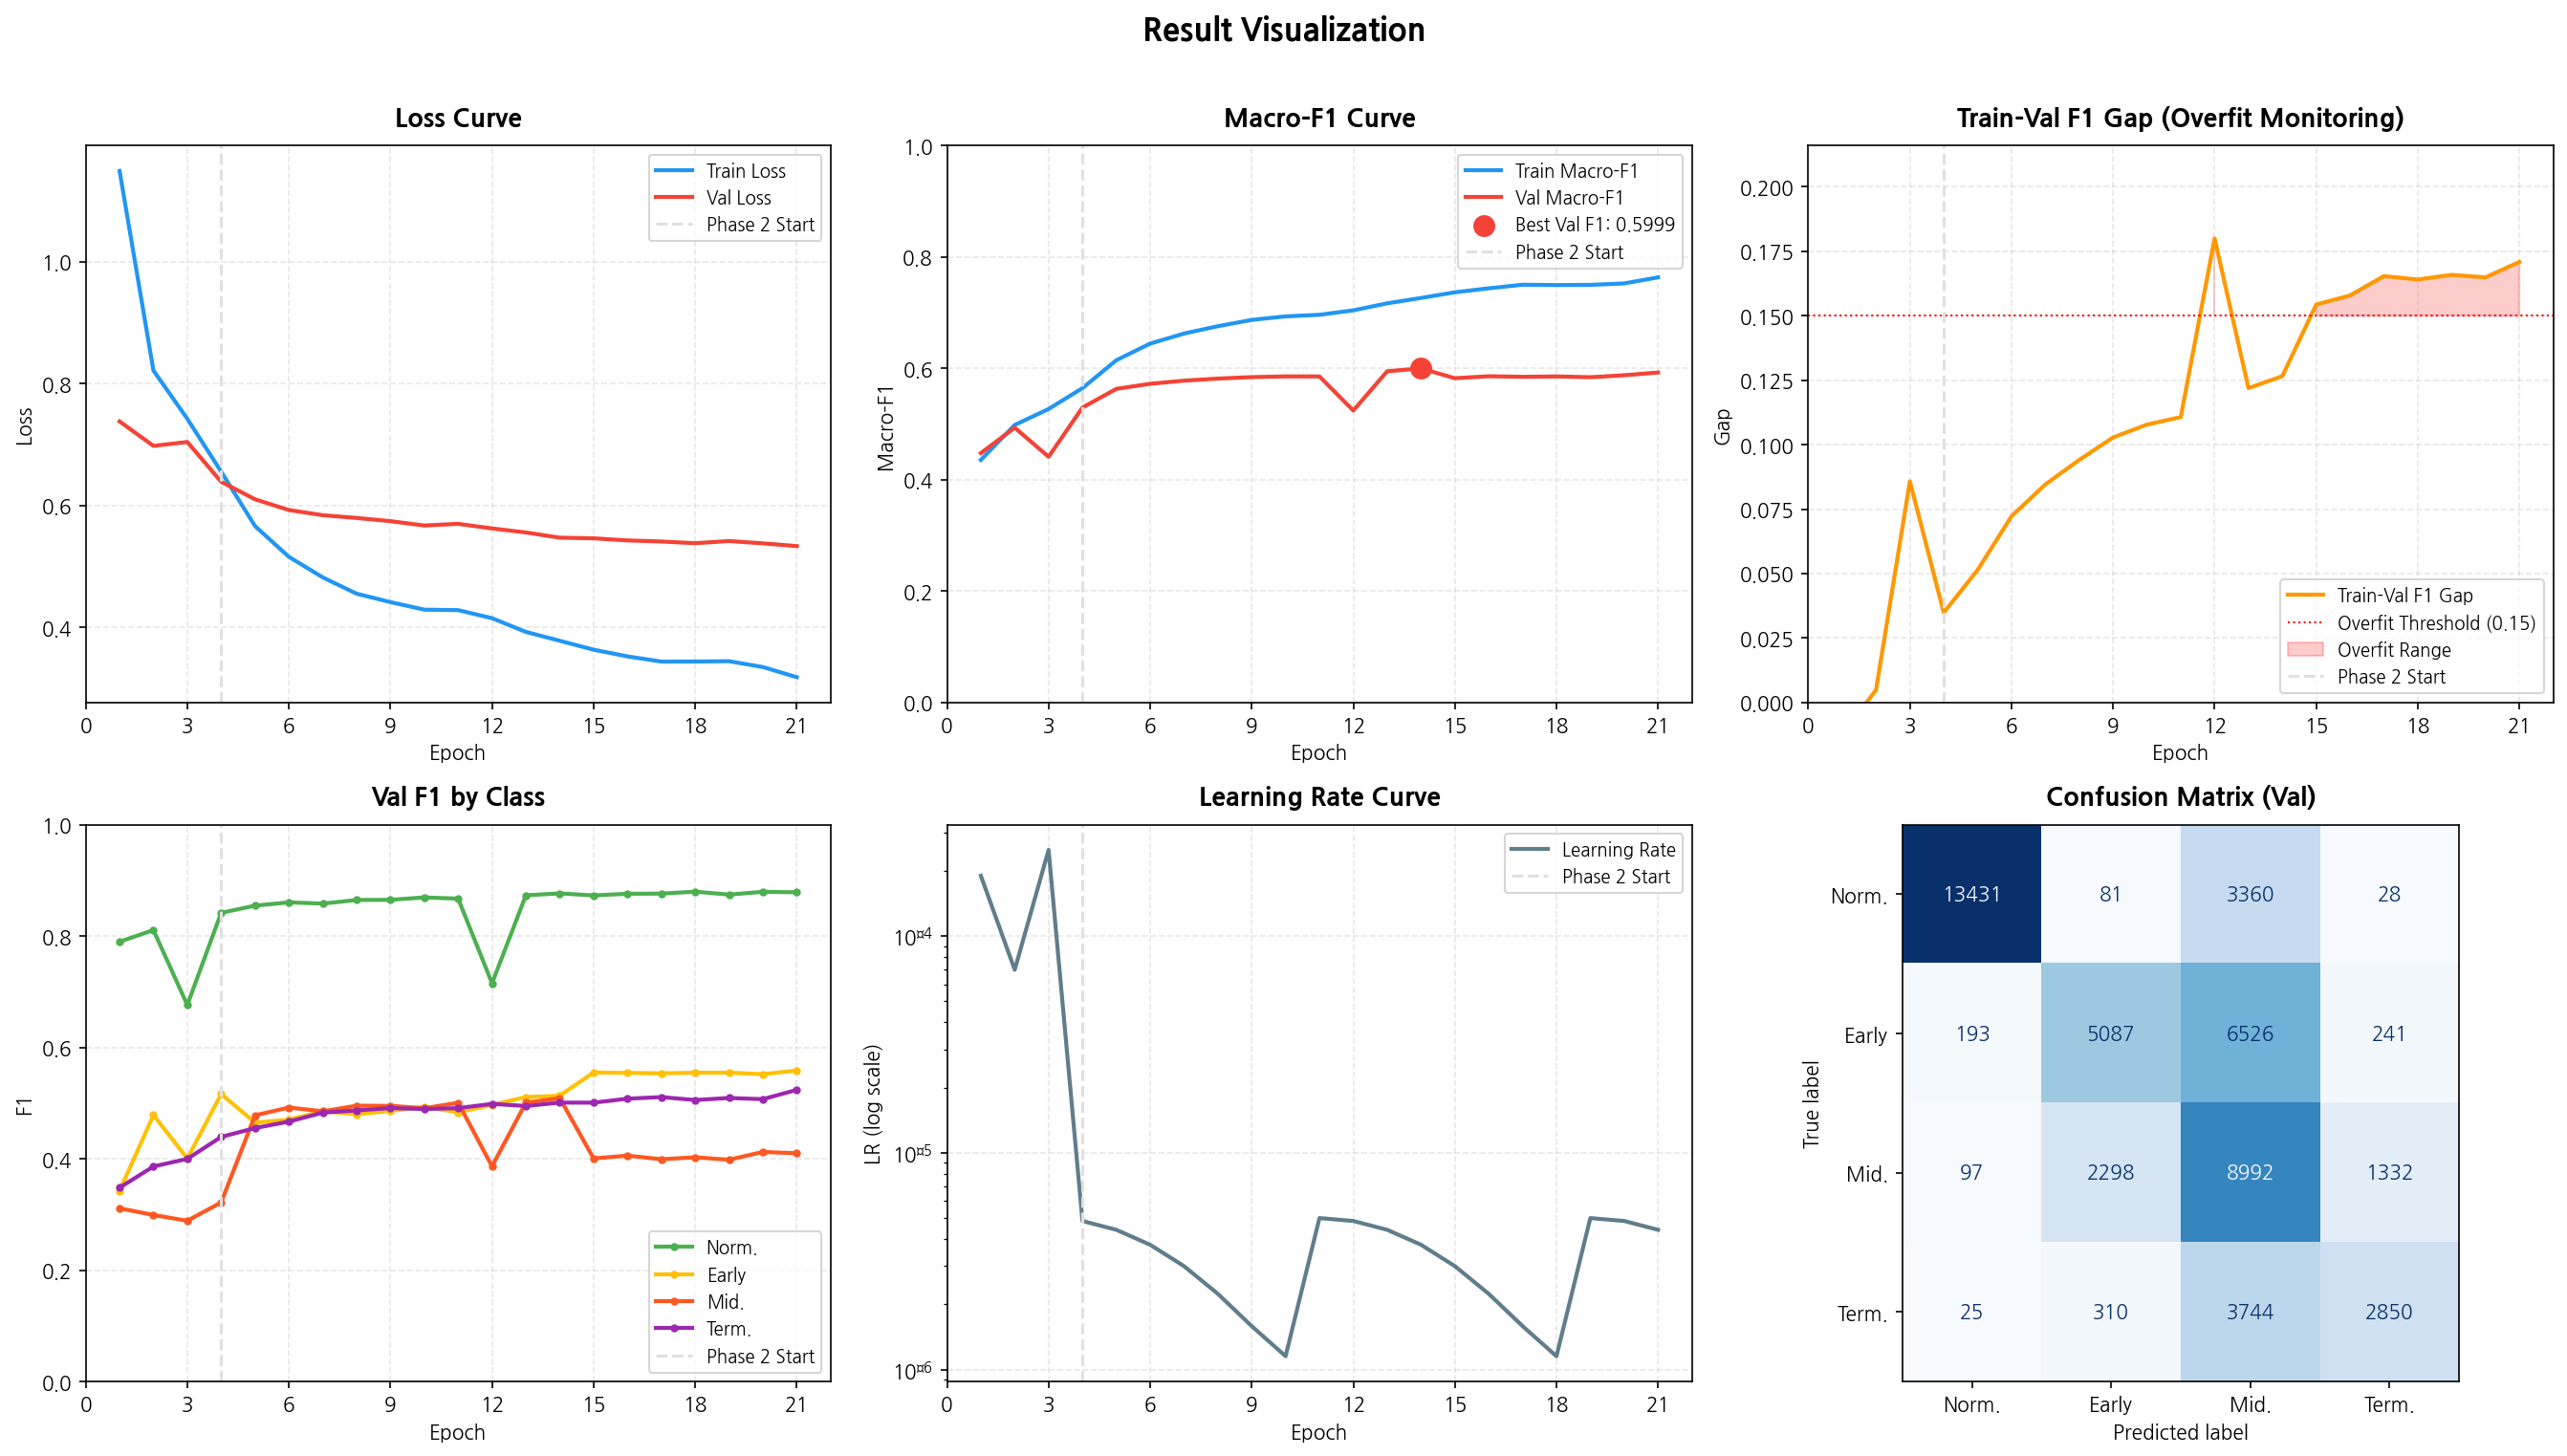

In [36]:
# ── Exp-2 B3: fc 이식 후 Fine-tuning ────────────────────
model_exp2 = EfficientNetCropDisease(NUM_CLASSES, DROPOUT, EXP2_VER).to(DEVICE)
transplant_fc(model_exp2, bl1_state_b3)

best_exp2_f1, exp2_lbl, exp2_pred = run_finetune(
    model_exp2, loaders_exp2, crit_exp2, f'{EXP2_DIR}/best_model.pth')
print(f'Exp-2 완료 — Best Val F1: {best_exp2_f1:.4f}')
IPImage(f'{EXP2_DIR}/training_curves.png')

## 6. Exp-3: B4 (선택 — 시간 여유 시 수행)

In [16]:
'''
EXP3_VER = 'B4'
EXP3_DIR = f'{CKPT_BASE}/exp3_b4'
Path(EXP3_DIR).mkdir(parents=True, exist_ok=True)

stats3_p = Path(f'{CKPT_BASE}/dataset_stats_b4.json')
if stats3_p.exists():
    s3 = json.load(open(stats3_p))
    MEAN3, STD3 = s3['mean'], s3['std']
    print(f'B4 통계 로드: {MEAN3}')
else:
    print('B4 통계 계산 중...')
    MEAN3, STD3 = compute_dataset_stats(train_s, model_ver='B4', num_workers=NUM_WORKERS)
    json.dump({'mean': MEAN3, 'std': STD3}, open(stats3_p, 'w'))

loaders_exp3 = build_dataloaders(
    train_s, val_s, test_s,
    batch_size  = max(BATCH_SIZE // 2, 16),  # B4는 메모리 더 필요
    num_workers = NUM_WORKERS,
    num_samples = NUM_SAMPLES_EP,
    mean        = MEAN3, std = STD3,
    model_ver   = EXP3_VER,
)
crit_exp3  = make_criterion()

'''

"\nEXP3_VER = 'B4'\nEXP3_DIR = f'{CKPT_BASE}/exp3_b4'\nPath(EXP3_DIR).mkdir(parents=True, exist_ok=True)\n\nstats3_p = Path(f'{CKPT_BASE}/dataset_stats_b4.json')\nif stats3_p.exists():\n    s3 = json.load(open(stats3_p))\n    MEAN3, STD3 = s3['mean'], s3['std']\n    print(f'B4 통계 로드: {MEAN3}')\nelse:\n    print('B4 통계 계산 중...')\n    MEAN3, STD3 = compute_dataset_stats(train_s, model_ver='B4', num_workers=NUM_WORKERS)\n    json.dump({'mean': MEAN3, 'std': STD3}, open(stats3_p, 'w'))\n\nloaders_exp3 = build_dataloaders(\n    train_s, val_s, test_s,\n    batch_size  = max(BATCH_SIZE // 2, 16),  # B4는 메모리 더 필요\n    num_workers = NUM_WORKERS,\n    num_samples = NUM_SAMPLES_EP,\n    mean        = MEAN3, std = STD3,\n    model_ver   = EXP3_VER,\n)\ncrit_exp3  = make_criterion()\n\n"

#### Exp-3 B4: BL-1 피처 추출 + MLP 학습 + fc 이식

In [17]:
'''
# ── Exp-3 B4: BL-1 피처 추출 + MLP 학습 + fc 이식 ──────
BL1_FEAT_TRAIN_B4 = f'{CKPT_BASE}/feat_b4/train'
BL1_FEAT_VAL_B4   = f'{CKPT_BASE}/feat_b4/val'

bl1_state_b4, best_bl1_b4 = run_feature_extraction(
    ver            = EXP3_VER,
    feat_dir_train = BL1_FEAT_TRAIN_B4,
    feat_dir_val   = BL1_FEAT_VAL_B4,
    samples_train  = train_s,
    samples_val    = val_s,
    mean           = MEAN3,
    std            = STD3,
    save_path      = f'{EXP3_DIR}/bl1_best_b4.pth',
)
IPImage(f'{EXP3_DIR}/bl1_curves_B4.png')
'''

"\n# ── Exp-3 B4: BL-1 피처 추출 + MLP 학습 + fc 이식 ──────\nBL1_FEAT_TRAIN_B4 = f'{CKPT_BASE}/feat_b4/train'\nBL1_FEAT_VAL_B4   = f'{CKPT_BASE}/feat_b4/val'\n\nbl1_state_b4, best_bl1_b4 = run_feature_extraction(\n    ver            = EXP3_VER,\n    feat_dir_train = BL1_FEAT_TRAIN_B4,\n    feat_dir_val   = BL1_FEAT_VAL_B4,\n    samples_train  = train_s,\n    samples_val    = val_s,\n    mean           = MEAN3,\n    std            = STD3,\n    save_path      = f'{EXP3_DIR}/bl1_best_b4.pth',\n)\nIPImage(f'{EXP3_DIR}/bl1_curves_B4.png')\n"

In [18]:
# ── Exp-3 B4: fc 이식 후 Fine-tuning ────────────────────
'''
model_exp3 = EfficientNetCropDisease(NUM_CLASSES, DROPOUT, EXP3_VER).to(DEVICE)
transplant_fc(model_exp3, bl1_state_b4)

best_exp3_f1, exp3_lbl, exp3_pred = run_finetune(
    model_exp3, loaders_exp3, crit_exp3, f'{EXP3_DIR}/best_model.pth')
print(f'Exp-3 완료 — Best Val F1: {best_exp3_f1:.4f}')
IPImage(f'{EXP3_DIR}/training_curves.png')
'''

"\nmodel_exp3 = EfficientNetCropDisease(NUM_CLASSES, DROPOUT, EXP3_VER).to(DEVICE)\ntransplant_fc(model_exp3, bl1_state_b4)\n\nbest_exp3_f1, exp3_lbl, exp3_pred = run_finetune(\n    model_exp3, loaders_exp3, crit_exp3, f'{EXP3_DIR}/best_model.pth')\nprint(f'Exp-3 완료 — Best Val F1: {best_exp3_f1:.4f}')\nIPImage(f'{EXP3_DIR}/training_curves.png')\n"

## 7. 실험 결과 비교 요약

In [37]:
print('\n' + '='*55)
print('실험 결과 비교')
print('='*55)
results = [
    ('BL-1  B0 Feature Extraction', best_bl1_f1),
    ('Exp-1 B0 Fine-tuning (BL-2)', best_exp1_f1),
    ('Exp-2 B3 Fine-tuning (핵심)',  best_exp2_f1),
]
if 'best_exp3_f1' in dir():
    results.append(('Exp-3 B4 Fine-tuning (선택)', best_exp3_f1))
baseline = best_exp1_f1
for name, f1 in results:
    diff = f1 - baseline
    mark = '← Baseline' if name.startswith('Exp-1') else ''
    print(f'  {name:35s} F1={f1:.4f}  ({diff:+.4f}) {mark}')
print('='*55)


실험 결과 비교
  BL-1  B0 Feature Extraction         F1=0.6604  (+0.0737) 
  Exp-1 B0 Fine-tuning (BL-2)         F1=0.5867  (+0.0000) ← Baseline
  Exp-2 B3 Fine-tuning (핵심)           F1=0.5999  (+0.0132) 


## 8. 시설/노지 분리 평가 (Exp-2 B3 결과 활용)
별도 학습 없이 Exp-2 모델로 환경별 성능 비교


In [20]:
# Exp-2 Best 모델 로드
ckpt2 = torch.load(f'{EXP2_DIR}/best_model.pth', map_location=DEVICE, weights_only=False)
model_exp2.load_state_dict(ckpt2['state_dict'])

fac_test = [s for s in test_s if s['env'] == '시설']
out_test  = [s for s in test_s if s['env'] == '노지']
print(f'시설 테스트: {len(fac_test):,}개 | 노지 테스트: {len(out_test):,}개')

res_fac = eval_epoch(model_exp2, make_test_loader(fac_test, MEAN2, STD2, EXP2_VER), crit_exp2)
res_out = eval_epoch(model_exp2, make_test_loader(out_test,  MEAN2, STD2, EXP2_VER), crit_exp2)
res_all = eval_epoch(model_exp2, make_test_loader(test_s,    MEAN2, STD2, EXP2_VER), crit_exp2)

print('\n' + '='*65)
print('시설/노지 분리 평가 (Exp-2 B3 통합 학습 모델)')
print('='*65)
for name, r in [('시설 테스트', res_fac), ('노지 테스트', res_out), ('통합 테스트', res_all)]:
    per = r['per_class_f1']
    print(f'  {name}: Macro-F1={r["f1"]:.4f} | '
          f'정상:{per[0]:.3f} 초기:{per[1]:.3f} 중기:{per[2]:.3f} 말기:{per[3]:.3f}')
diff = res_fac['f1'] - res_out['f1']
print(f'\n  시설-노지 F1 차이: {diff:+.4f} (작을수록 환경 일반화 성공)')
print('='*65)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, r, name in zip(axes, [res_fac, res_out], ['시설', '노지']):
    cm = confusion_matrix(r['labels'], r['preds'])
    ConfusionMatrixDisplay(cm,
        display_labels=['Norm.','Early','Mid.','Term.']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name} Confusion Matrix | F1={r["f1"]:.4f}', fontsize=12)
plt.tight_layout()
plt.savefig(f'{EXP2_DIR}/env_split_cm.png', dpi=150)
plt.show()

시설 테스트: 24,846개 | 노지 테스트: 23,882개

시설/노지 분리 평가 (Exp-2 B3 통합 학습 모델)
  시설 테스트: Macro-F1=0.7611 | 정상:0.992 초기:0.720 중기:0.601 말기:0.732
  노지 테스트: Macro-F1=0.7315 | 정상:0.990 초기:0.726 중기:0.614 말기:0.596
  통합 테스트: Macro-F1=0.7486 | 정상:0.991 초기:0.723 중기:0.608 말기:0.673

  시설-노지 F1 차이: +0.0296 (작을수록 환경 일반화 성공)


## 9. 고추 Cross-Environment 분석 + Grad-CAM
시설 고추(crop_code=2) vs 노지 고추(crop_code=1)


In [21]:

import cv2
from PIL import Image as PILImage
from torchvision import transforms as T

_pre_b3 = T.Compose([
    T.Resize((300, 300)),
    T.ToTensor(),
    T.Normalize(MEAN2, STD2),
])

class GradCAM:
    def __init__(self, model):
        self.model = model; self.act = self.grad = None
        model.features[-1].register_forward_hook(
            lambda m, i, o: setattr(self, 'act', o.detach()))
        model.features[-1].register_full_backward_hook(
            lambda m, gi, go: setattr(self, 'grad', go[0].detach()))
    def generate(self, tensor, target=None):
        self.model.eval()
        tensor = tensor.clone().requires_grad_(True)
        logits = self.model(tensor)
        if target is None: target = logits.argmax(1).item()
        self.model.zero_grad(); logits[0, target].backward()
        w   = self.grad.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((w * self.act).sum(1).squeeze()).cpu().numpy()
        return (cam - cam.min()) / (cam.max() - cam.min() + 1e-8), target
'''
fac_pepper = [s for s in fac_test if s['crop_code'] == 2]
out_pepper  = [s for s in out_test  if s['crop_code'] == 1]
print(f'시설 고추: {len(fac_pepper)}개 | 노지 고추: {len(out_pepper)}개')

res_fp = eval_epoch(model_exp2, make_test_loader(fac_pepper, MEAN2, STD2, EXP2_VER), crit_exp2)
res_op = eval_epoch(model_exp2, make_test_loader(out_pepper,  MEAN2, STD2, EXP2_VER), crit_exp2)
print(f'\n시설 고추 F1: {res_fp["f1"]:.4f} | 노지 고추 F1: {res_op["f1"]:.4f}')
print(f'환경 간 차이: {res_fp["f1"]-res_op["f1"]:+.4f}')
'''

'\nfac_pepper = [s for s in fac_test if s[\'crop_code\'] == 2]\nout_pepper  = [s for s in out_test  if s[\'crop_code\'] == 1]\nprint(f\'시설 고추: {len(fac_pepper)}개 | 노지 고추: {len(out_pepper)}개\')\n\nres_fp = eval_epoch(model_exp2, make_test_loader(fac_pepper, MEAN2, STD2, EXP2_VER), crit_exp2)\nres_op = eval_epoch(model_exp2, make_test_loader(out_pepper,  MEAN2, STD2, EXP2_VER), crit_exp2)\nprint(f\'\n시설 고추 F1: {res_fp["f1"]:.4f} | 노지 고추 F1: {res_op["f1"]:.4f}\')\nprint(f\'환경 간 차이: {res_fp["f1"]-res_op["f1"]:+.4f}\')\n'

In [22]:
# 고추 Grad-CAM 시각화 (환경별, risk 클래스별 1장)
'''
gcam = GradCAM(model_exp2)

def show_gradcam_grid(samples, env_name, preprocess, size=300):
    from collections import defaultdict
    by_risk = defaultdict(list)
    for s in samples: by_risk[s['risk_label']].append(s)
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle(f'{env_name} 고추 Grad-CAM (Exp-2 B3)', fontsize=13, fontweight='bold')
    for risk in range(4):
        if not by_risk[risk]:
            axes[0][risk].axis('off'); axes[1][risk].axis('off'); continue
        s    = by_risk[risk][0]
        # zip에서 이미지 읽기
        import zipfile, io
        with zipfile.ZipFile(s["zip_path"], "r") as zf:
            buf = zf.read(s["inner_path"])
        arr     = np.frombuffer(buf, dtype=np.uint8)
        img_cv  = cv2.imdecode(arr, cv2.IMREAD_COLOR)
        img_pil = PILImage.fromarray(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
        tensor  = preprocess(img_pil).unsqueeze(0).to(DEVICE)
        cam, pred = gcam.generate(tensor)
        img_cv  = cv2.resize(img_cv, (size, size))
        heat    = cv2.applyColorMap(np.uint8(255 * cv2.resize(cam, (size, size))),
                                     cv2.COLORMAP_JET)
        overlay = cv2.addWeighted(img_cv, 0.5, heat, 0.5, 0)
        axes[0][risk].imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
        axes[0][risk].set_title(f'실제: {RISK_CLASSES[risk]}', fontsize=10)
        axes[0][risk].axis('off')
        axes[1][risk].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        axes[1][risk].set_title(f'예측: {RISK_CLASSES[pred]}', fontsize=10)
        axes[1][risk].axis('off')
    plt.tight_layout()
    plt.savefig(f'{EXP2_DIR}/{env_name}_pepper_gradcam.png', dpi=150); plt.show()

show_gradcam_grid(fac_pepper, '시설', _pre_b3)
show_gradcam_grid(out_pepper,  '노지', _pre_b3)
'''

'\ngcam = GradCAM(model_exp2)\n\ndef show_gradcam_grid(samples, env_name, preprocess, size=300):\n    from collections import defaultdict\n    by_risk = defaultdict(list)\n    for s in samples: by_risk[s[\'risk_label\']].append(s)\n    fig, axes = plt.subplots(2, 4, figsize=(16, 8))\n    fig.suptitle(f\'{env_name} 고추 Grad-CAM (Exp-2 B3)\', fontsize=13, fontweight=\'bold\')\n    for risk in range(4):\n        if not by_risk[risk]:\n            axes[0][risk].axis(\'off\'); axes[1][risk].axis(\'off\'); continue\n        s    = by_risk[risk][0]\n        # zip에서 이미지 읽기\n        import zipfile, io\n        with zipfile.ZipFile(s["zip_path"], "r") as zf:\n            buf = zf.read(s["inner_path"])\n        arr     = np.frombuffer(buf, dtype=np.uint8)\n        img_cv  = cv2.imdecode(arr, cv2.IMREAD_COLOR)\n        img_pil = PILImage.fromarray(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))\n        tensor  = preprocess(img_pil).unsqueeze(0).to(DEVICE)\n        cam, pred = gcam.generate(tensor)\n     

## 10. 개방형 일반화 평가 (held-out 6그룹)
학습에 없던 작물에서 진행단계 추정 가능 여부 검증


In [23]:
all_heldout = [s for s in all_heldout if 'facility_01_가지' not in s['group_id']]
print(all_heldout[0])
heldout_loader = make_test_loader(all_heldout, MEAN2, STD2, EXP2_VER)
res_held = eval_epoch(model_exp2, heldout_loader, crit_exp2)

print('\n' + '='*65)
print('개방형 일반화 평가 (held-out 6그룹)')
print('='*65)
per = res_held['per_class_f1']
print(f'  학습 내 test F1: {best_exp2_f1:.4f}')
print(f'  held-out  F1:    {res_held["f1"]:.4f}')
print(f'  일반화 유지율:   {res_held["f1"]/best_exp2_f1*100:.1f}%')
print(f'  클래스별: 정상:{per[0]:.3f} 초기:{per[1]:.3f} 중기:{per[2]:.3f} 말기:{per[3]:.3f}')
print('='*65)

# 그룹별 세부 성능
from collections import defaultdict
by_group = defaultdict(list)
for s in all_heldout: by_group[(s['env'], s['crop_code'])].append(s)
print('\n  [그룹별 held-out 성능]')
HELDOUT_NAMES = {
    ("시설", 1): "가지", ("시설", 6): "수박", ("시설", 10): "참외",
    ("노지", 5): "양배추", ("노지", 7): "잎마름병(토마토)", ("노지", 10): "호박",
}
for (env, crop), slist in sorted(by_group.items()):
    r_g  = eval_epoch(model_exp2, make_test_loader(slist, MEAN2, STD2, EXP2_VER), crit_exp2)
    name = HELDOUT_NAMES.get((env, crop), f"crop{crop}")
    print(f'  {env:3s} {name:15s} (crop={crop}): F1={r_g["f1"]:.4f} | n={len(slist):,}')

{'zip_path': '/workspace/data/facility_06_수박.zip', 'inner_path': 'facility_06_수박/images/img_0000001.jpg', 'risk_label': 0, 'crop_code': 6, 'crop_folder': '06.수박', 'env': '시설', 'group_id': 'facility_06_수박', 'group_type': 'heldout_group', 'group_key': ('facility_06_수박', 0)}

개방형 일반화 평가 (held-out 6그룹)
  학습 내 test F1: 0.7569
  held-out  F1:    0.5436
  일반화 유지율:   71.8%
  클래스별: 정상:0.960 초기:0.327 중기:0.362 말기:0.525

  [그룹별 held-out 성능]
  노지  양배추             (crop=5): F1=0.5901 | n=36,078
  노지  잎마름병(토마토)       (crop=7): F1=0.4796 | n=15,070
  노지  호박              (crop=10): F1=0.5292 | n=17,520
  시설  수박              (crop=6): F1=0.4360 | n=27,576
  시설  참외              (crop=10): F1=0.4889 | n=28,690


In [24]:
# held-out Confusion Matrix
cm_held = confusion_matrix(res_held['labels'], res_held['preds'])
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm_held,
    display_labels=['Norm.','Early','Mid.','Term.']).plot(
    ax=ax, cmap='Oranges', colorbar=False)
ax.set_title(f'held-out Confusion Matrix | F1={res_held["f1"]:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./heldout_cm.png', dpi=150); plt.show()

# held-out Grad-CAM (그룹별 1장)
gcam = GradCAM(model_exp2)
print('\nheld-out Grad-CAM 시각화')
for (env, crop), slist in list(sorted(by_group.items()))[:4]:
    if not slist: continue
    s    = slist[0]
    name = HELDOUT_NAMES.get((env, crop), f"crop{crop}")
    # zip에서 이미지 읽기 (img_path 없음)
    import zipfile, io
    with zipfile.ZipFile(s["zip_path"], "r") as zf:
        buf = zf.read(s["inner_path"])
    arr    = np.frombuffer(buf, dtype=np.uint8)
    img_cv = cv2.imdecode(arr, cv2.IMREAD_COLOR)
    img_pil = PILImage.fromarray(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
    tensor  = _pre_b3(img_pil).unsqueeze(0).to(DEVICE)
    cam, pred = gcam.generate(tensor)
    img_cv  = cv2.resize(img_cv, (300, 300))
    heat    = cv2.applyColorMap(np.uint8(255 * cv2.resize(cam, (300, 300))), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(img_cv, 0.5, heat, 0.5, 0)
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f'{env} {name} | 실제: {RISK_CLASSES[s["risk_label"]]}')
    axes[0].axis('off')
    axes[1].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[1].set_title(f'Grad-CAM | 예측: {RISK_CLASSES[pred]}')
    axes[1].axis('off')
    plt.tight_layout(); plt.show()


held-out Grad-CAM 시각화


## 11. Exp-4: B3 + Soft Labeling (선택)
Exp-2 성능 부족 시 수행. 중기↔초기 혼동 감소 목적.


Soft Label 행렬 (alpha=0.10):
  정상  : ['0.95', '0.05', '0.00', '0.00']
  초기  : ['0.05', '0.90', '0.05', '0.00']
  중기  : ['0.00', '0.05', '0.90', '0.05']
  말기  : ['0.00', '0.00', '0.05', '0.95']
▶ Phase 1: features 동결
[Ep  1/35 Ph1] Tr 0.4191/0.4994 Val 0.3137/0.5349 Gap=-0.036 [85.3s]
  정상:0.883 초기:0.582 중기:0.165 말기:0.510
  ✔ Best 저장 (0.5349)
[Ep  2/35 Ph1] Tr 0.3529/0.5552 Val 0.2806/0.5897 Gap=-0.035 [75.9s]
  정상:0.903 초기:0.581 중기:0.332 말기:0.543
  ✔ Best 저장 (0.5897)
[Ep  3/35 Ph1] Tr 0.3323/0.5765 Val 0.2521/0.6200 Gap=-0.043 [74.3s]
  정상:0.930 초기:0.586 중기:0.416 말기:0.548
  ✔ Best 저장 (0.6200)
[Ep  4/35 Ph1] Tr 0.3177/0.5908 Val 0.2417/0.6329 Gap=-0.042 [73.6s]
  정상:0.932 초기:0.581 중기:0.446 말기:0.573
  ✔ Best 저장 (0.6329)
[Ep  5/35 Ph1] Tr 0.3084/0.6021 Val 0.2376/0.6306 Gap=-0.029 [73.6s]
  정상:0.936 초기:0.614 중기:0.404 말기:0.568
[Ep  6/35 Ph1] Tr 0.3002/0.6116 Val 0.2304/0.6390 Gap=-0.027 [73.9s]
  정상:0.944 초기:0.608 중기:0.431 말기:0.573
  ✔ Best 저장 (0.6390)

▶ Phase 2: 차등 lr (epoch 7)
[Ep  7/35 

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

학습 곡선 저장: /workspace/checkpoints/exp4_b3_softlabel/training_curves.png

완료 — Best Val F1: 0.7559

Exp-4 완료 — Best Val F1: 0.7559
Exp-2 대비: -0.0010


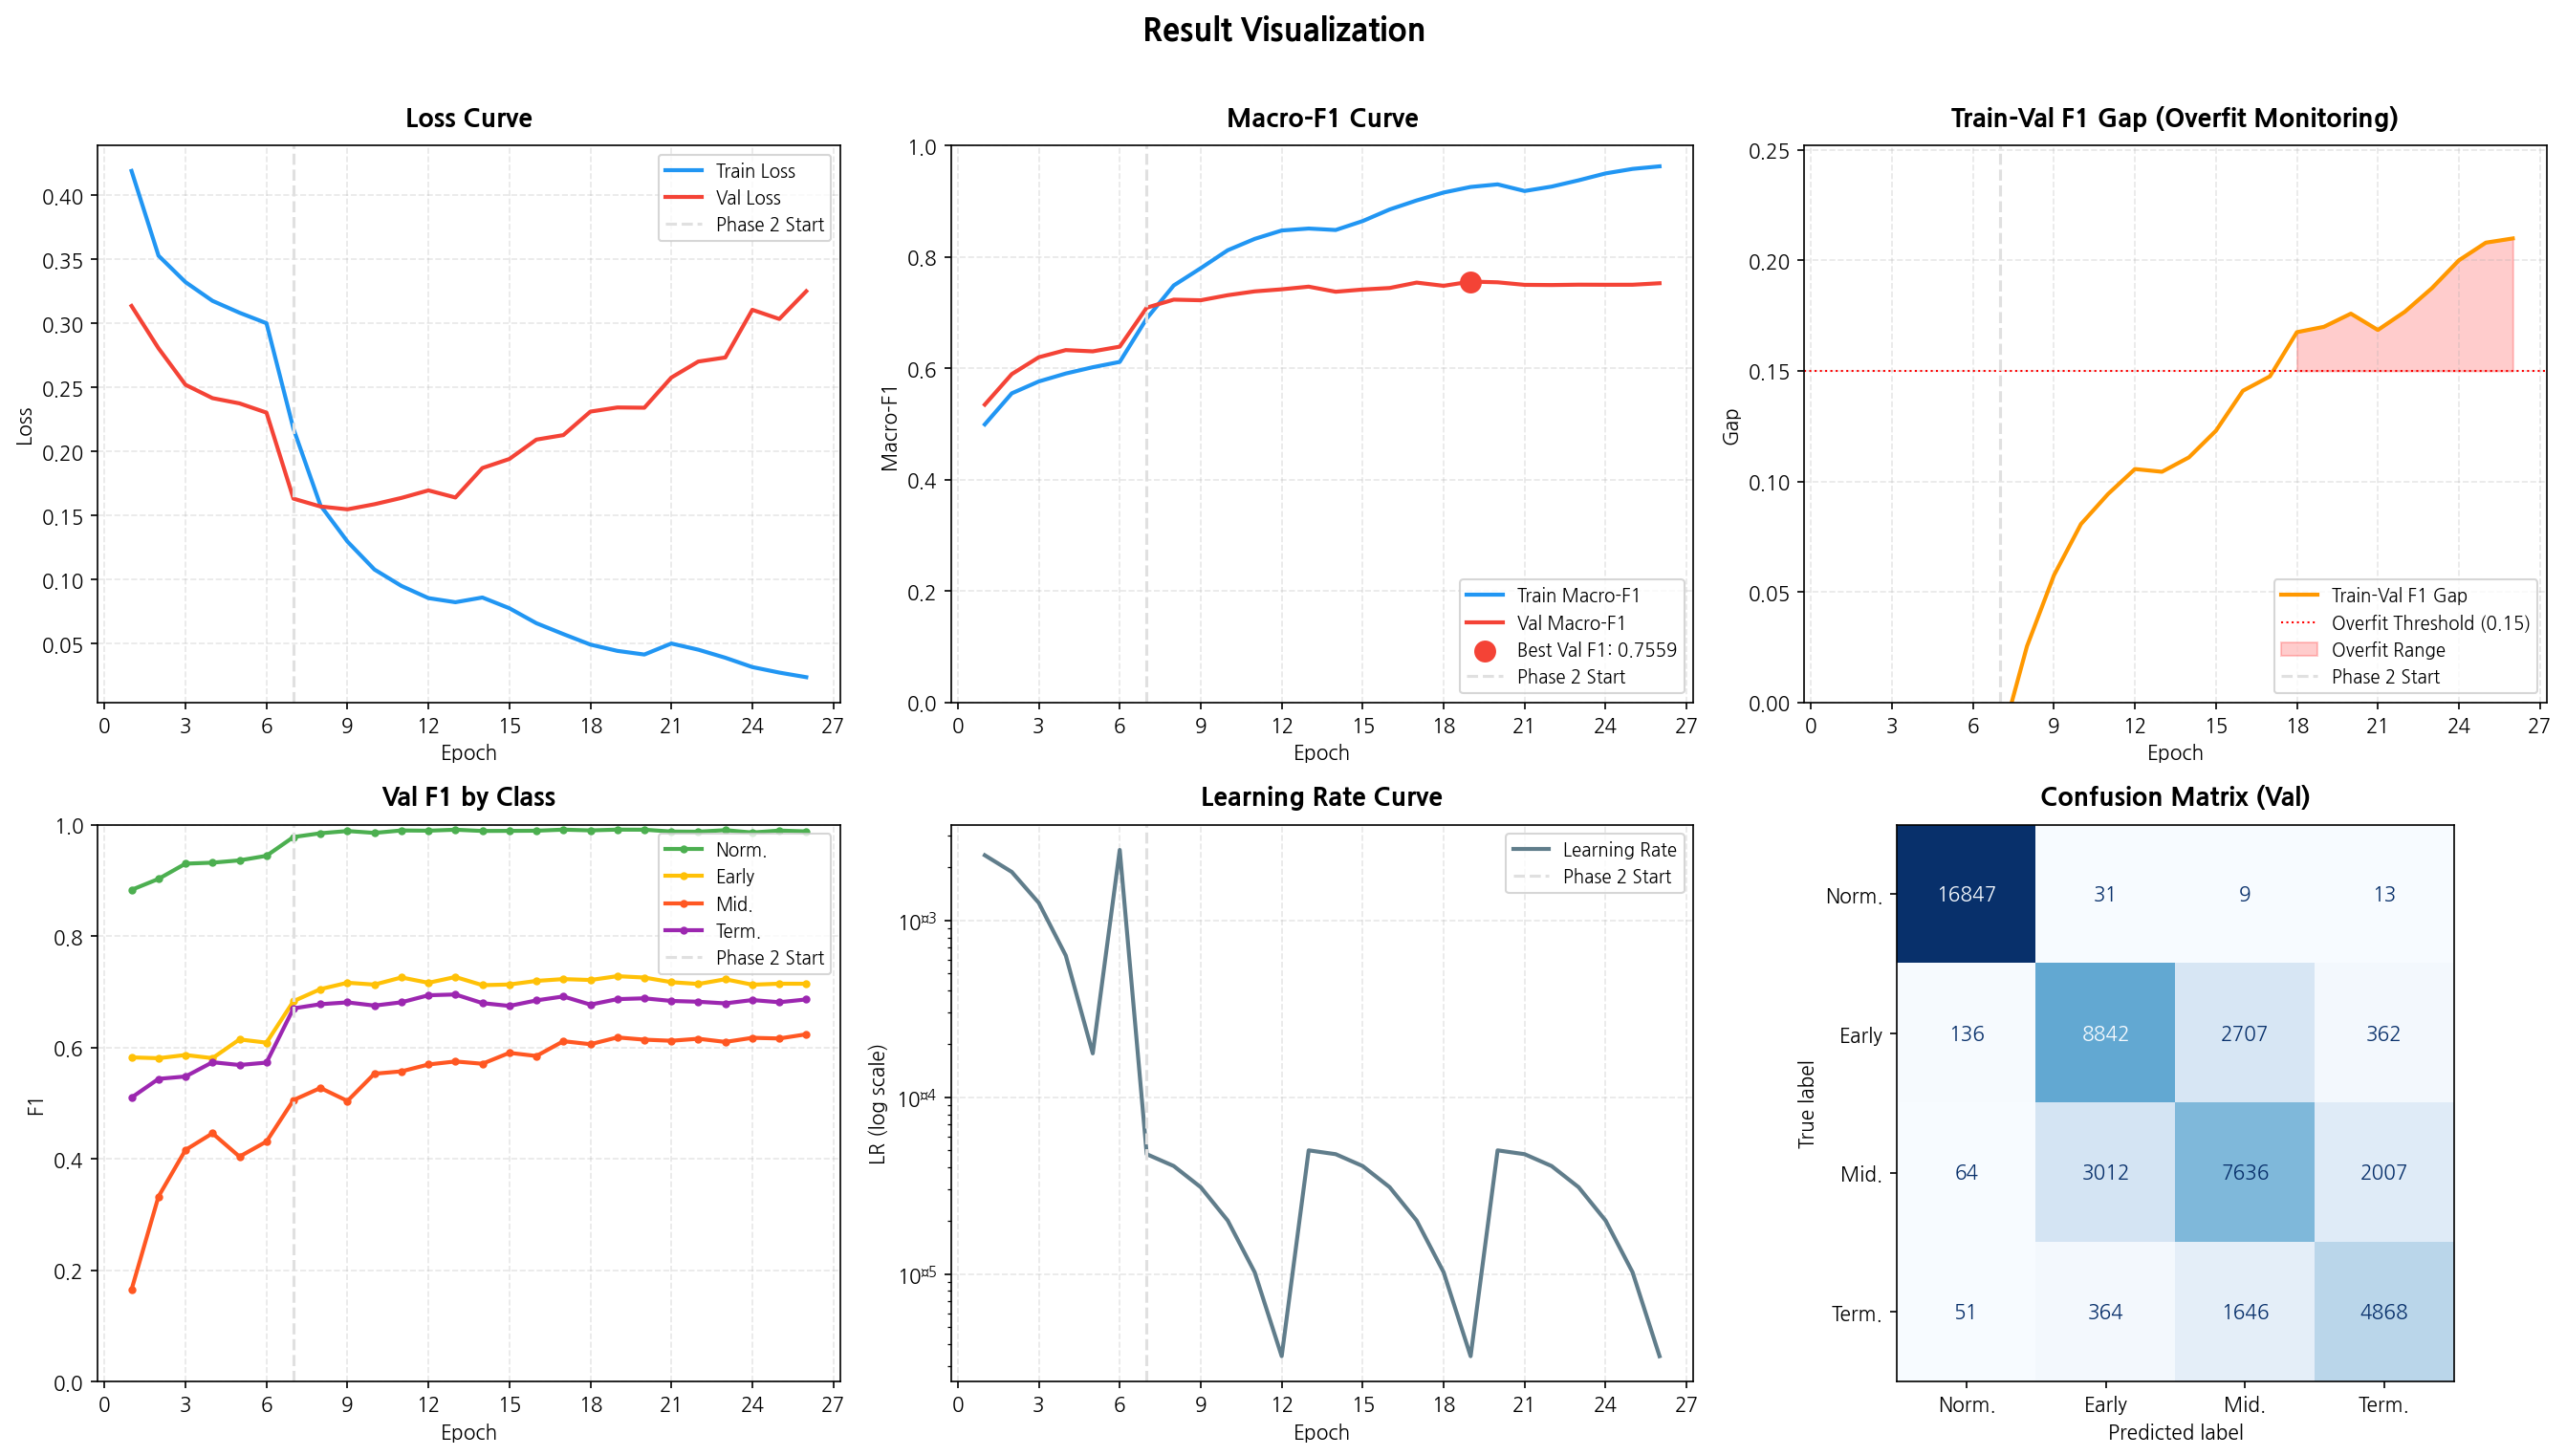

In [25]:
EXP4_DIR = f'{CKPT_BASE}/exp4_b3_softlabel'
Path(EXP4_DIR).mkdir(parents=True, exist_ok=True)

model_exp4 = EfficientNetCropDisease(NUM_CLASSES, DROPOUT, 'B3').to(DEVICE)
'''
ckpt_exp2 = torch.load(f'{EXP2_DIR}/best_model.pth',
                        map_location=DEVICE, weights_only=False)
model_exp4.load_state_dict(ckpt_exp2['state_dict'])  # 전체 가중치 이식
'''
crit_exp4  = SoftLabelLoss(num_classes=4, alpha=0.10, focal_gamma=GAMVAL).to(DEVICE)

print('Soft Label 행렬 (alpha=0.10):')
for i, row in enumerate(crit_exp4.soft_label_matrix.tolist()):
    vals = [f'{v:.2f}' for v in row]
    print(f'  {RISK_CLASSES[i]:4s}: {vals}')

best_exp4_f1, _, _ = run_finetune(
    model_exp4, loaders_exp2, crit_exp4, f'{EXP4_DIR}/best_model.pth')
print(f'\nExp-4 완료 — Best Val F1: {best_exp4_f1:.4f}')
print(f'Exp-2 대비: {best_exp4_f1 - best_exp2_f1:+.4f}')
IPImage(f'{EXP4_DIR}/training_curves.png')